# Event Selection

**_must run with dfs will all reconstructed slices and tracks_**

This notebook runs the full event selection, evaluating selection performance

- makes mode breakdown bar plots for each selection stage
- makes purity/efficiency summary plots

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config_new import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers_new import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [3]:
show_plot = True


save_fig = True
save_fig_base_dir = "/exp/sbnd/data/users/munjung/xsec/PLOTS/numuCC_1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
# today_str = "thesis"
save_fig_dir = path.join(save_fig_base_dir, f"event_selection-{today_str}")
if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)


save_content = True
save_content_base_dir = "/exp/sbnd/data/users/munjung/xsec/RESULTS/numuCC_1p0pi"
save_content_dir = path.join(save_content_base_dir, f"event_selection-{today_str}")
if save_content:
    if not path.exists(save_content_dir):
        makedirs(save_content_dir)
    print("saving nevts in ", save_content_dir)

saving plots in  /exp/sbnd/data/users/munjung/xsec/PLOTS/numuCC_1p0pi/event_selection-20260722
saving nevts in  /exp/sbnd/data/users/munjung/xsec/RESULTS/numuCC_1p0pi/event_selection-20260722


In [4]:
# MC
# df_dir_mc = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_041007__sel_all-mc-BNB_cosmics"
# filename_str_mc = "sel_all"
# keys2load_mc = ['evt', 'trk', 'hdr'] #'hit0', 'hit1', 'hit2',
# df_mc = dfs_from_dir(search_dir=df_dir_mc, filename_str=filename_str_mc, keys2load=keys2load_mc, n_max_concat=200)

# # Data
# df_dir_data = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230859__sel_all-data-1e20"
# filename_str_data = "sel_all"
# keys2load_data = ['evt', 'trk', 'hdr', 'bnbpot', 'trigger']
# df_data = dfs_from_dir(search_dir=df_dir_data, filename_str=filename_str_data, keys2load=keys2load_data, n_max_concat=999)

# # LowE Dirt
# df_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/MC/2026_05_11_040638__sel_all-mc-dirt"
# keys2load_lowE = ['hdr', 'evt', 'trk']
# df_lowE = dfs_from_dir(search_dir=df_dir, filename_str="sel_all", keys2load=keys2load_lowE, n_max_concat=200)

# # OffBeam
# df_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/data/2026_05_11_035756__sel_all-data-OffBeamLight"
# keys2load_offbeam = ['hdr', 'evt', 'trk']
# df_offbeam = dfs_from_dir(search_dir=df_dir, filename_str="_all", keys2load=keys2load_offbeam, n_max_concat=200)

# # Intime
# df_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09/MC/2026_05_11_040132__sel_all-mc-Intime"
# keys2load_intime = ['hdr', 'evt', 'trk']
# df_intime = dfs_from_dir(search_dir=df_dir, filename_str="all", keys2load=keys2load_intime, n_max_concat=200)

In [5]:
# # MC
df_dir_mc = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics"
filename_str_mc = "sel_2prong"
keys2load_mc = ['evt', 'hdr'] #'hit0', 'hit1', 'hit2',
df_mc = dfs_from_dir(search_dir=df_dir_mc, filename_str=filename_str_mc, keys2load=keys2load_mc, n_max_concat=9999)

# Data
df_dir_data = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20"
filename_str_data = "sel_2prong"
keys2load_data = ['evt', 'hdr', 'bnbpot']
df_data = dfs_from_dir(search_dir=df_dir_data, filename_str=filename_str_data, keys2load=keys2load_data, n_max_concat=9999)

# LowE Dirt
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt"
keys2load_lowE = ['hdr', 'evt']
df_lowE = dfs_from_dir(search_dir=df_dir, filename_str="sel_2prong", keys2load=keys2load_lowE, n_max_concat=200)

# OffBeam
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight"
keys2load_offbeam = ['hdr', 'evt']
df_offbeam = dfs_from_dir(search_dir=df_dir, filename_str="_2prong", keys2load=keys2load_offbeam, n_max_concat=9999)

# Intime
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime"
keys2load_intime = ['hdr', 'evt']
df_intime = dfs_from_dir(search_dir=df_dir, filename_str="_2prong", keys2load=keys2load_intime, n_max_concat=9999)

Found 1949 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafp

100%|██████████| 1949/1949 [12:24<00:00,  2.62it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 97 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_14.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_

100%|██████████| 97/97 [01:22<00:00,  1.17it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2prong-mc-dirt_104.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_135816__sel_2prong-mc-dirt/sel_2pro

...

REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 190 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamL

100%|██████████| 190/190 [01:14<00:00,  2.54it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 192 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232_

100%|██████████| 192/192 [01:17<00:00,  2.48it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!


In [6]:
# -- Assign event and track DataFrames for each sample
# mc_hdr_df, mc_evt_df, mc_trk_df = df_mc["hdr"], df_mc["evt"], df_mc["trk"]
# data_hdr_df, data_evt_df, data_trk_df = df_data["hdr"], df_data["evt"], df_data["trk"]
# dirt_hdr_df, dirt_evt_df, dirt_trk_df = df_lowE["hdr"], df_lowE["evt"], df_lowE["trk"]
# offbeam_hdr_df, offbeam_evt_df, offbeam_trk_df = df_offbeam["hdr"], df_offbeam["evt"], df_offbeam["trk"]
# intime_hdr_df, intime_evt_df, intime_trk_df = df_intime["hdr"], df_intime["evt"], df_intime["trk"]

mc_hdr_df, mc_evt_df = df_mc["hdr"], df_mc["evt"]
data_hdr_df, data_evt_df = df_data["hdr"], df_data["evt"]
dirt_hdr_df, dirt_evt_df = df_lowE["hdr"], df_lowE["evt"]
offbeam_hdr_df, offbeam_evt_df = df_offbeam["hdr"], df_offbeam["evt"]
intime_hdr_df, intime_evt_df = df_intime["hdr"], df_intime["evt"]

# -- Exposure calculation for BNB data
data_tot_pot = data_hdr_df['pot'].sum()
pot_str = get_pot_str(data_tot_pot)
data_evt_df["pot_weight"] = 1.0  # np.ones(len(data_evt_df))
# data_trk_df["pot_weight"] = 1.0  # np.ones(len(data_trk_df))
data_gates = data_hdr_df.nbnbinfo.sum()
print(f"data_tot_pot: {data_tot_pot:.3e}", f"data tot gates : {data_gates:.3e}")

# -- BNB MC scaling
mc_tot_pot = mc_hdr_df['pot'].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot if mc_tot_pot > 0 else 0
mc_evt_df["pot_weight"] = mc_pot_scale
# mc_trk_df["pot_weight"] = mc_pot_scale
print(f"mc_tot_pot: {mc_tot_pot:.3e}", f"mc_pot_scale: {mc_pot_scale:.3e}")

# -- Dirt sample scaling
dirt_tot_pot = dirt_hdr_df['pot'].sum()
dirt_pot_scale = data_tot_pot / dirt_tot_pot if dirt_tot_pot > 0 else 0
dirt_evt_df["pot_weight"] = dirt_pot_scale
# dirt_trk_df["pot_weight"] = dirt_pot_scale
print(f"dirt_tot_pot: {dirt_tot_pot:.3e}", f"dirt_pot_scale: {dirt_pot_scale:.3e}")

# -- Offbeam exposure scaling
f = 0.08
offbeam_gates = offbeam_hdr_df.loc[offbeam_hdr_df['first_in_subrun'] == 1, 'noffbeambnb'].sum()
scale_offbeam_to_lightdata = (1-f) * data_gates / offbeam_gates if offbeam_gates > 0 else 0
offbeam_evt_df["gates_weight"] = scale_offbeam_to_lightdata
offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata
# offbeam_trk_df["pot_weight"] = scale_offbeam_to_lightdata
print(f"offbeam cosmics data gates: {offbeam_gates:.2e}", f"goal scale: {scale_offbeam_to_lightdata:.2f}")

# -- Intime MC cosmics scaling
intime_gates = intime_hdr_df.loc[intime_hdr_df['first_in_subrun'] == 1, 'ngenevt'].sum()
scale_intime_to_lightdata = (1-f) * data_gates / intime_gates if intime_gates > 0 else 0
intime_evt_df["gates_weight"] = scale_intime_to_lightdata
intime_evt_df["pot_weight"] = scale_intime_to_lightdata
# intime_trk_df["pot_weight"] = scale_intime_to_lightdata
print(f"intime cosmics data gates: {intime_gates:.2e}", f"goal scale: {scale_intime_to_lightdata:.2f}")

data_tot_pot: 8.699e+19 data tot gates : 1.894e+07
mc_tot_pot: 5.485e+20 mc_pot_scale: 1.586e-01
dirt_tot_pot: 1.481e+20 dirt_pot_scale: 5.873e-01
offbeam cosmics data gates: 7.92e+07 goal scale: 0.22
intime cosmics data gates: 9.93e+07 goal scale: 0.18


In [7]:
pot_str = get_pot_str(data_tot_pot)
plot_labels_bar = ["Events (POT={})".format(pot_str), "", ""]
plot_labels_hist = ["", "Events (POT={})".format(pot_str), ""]

In [8]:
def plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=True):

    ret_dict = {}

    for bar_type in ["topology", "genie"]: # "nu_cosmics"
        save_name = save_fig_dir + "/bar_plot-{}-{}.png".format(bar_type, stage_key)
        this_ret = bar_plot(breakdown_type=bar_type,
                            mc_df=mc_df, intime_df=intime_df, dirt_df=dirt_df,
                            show_plot=show_plot, plot_labels=plot_labels_bar,
                            save_fig=save_fig, save_name=save_name)
        ret_dict[bar_type] = this_ret

    return ret_dict

# Event Selection

In [9]:
# save breakdowns for summary plots
breakdown_dict = {"topology": {}, "genie": {}}

# save dfs per stage, df_dict used for efficiency plot
df_dict = {} 
df_dict_data = {}
df_dict_intime = {} 
df_dict_offbeam = {}
df_dict_dirt = {}

## Cosmic Rejection

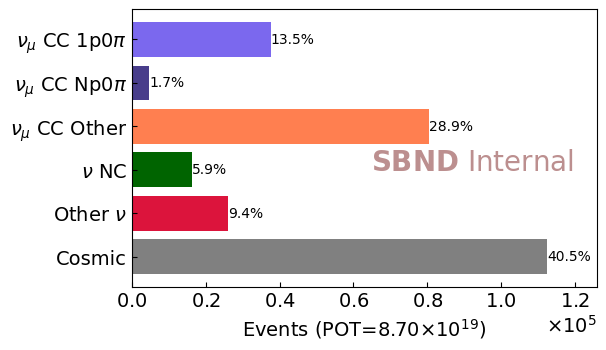

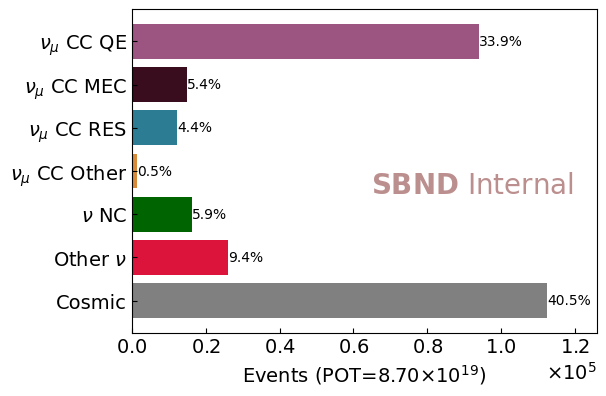

In [10]:
stage_key = "allreco"

mc_df     = mc_evt_df
data_df   = data_evt_df
intime_df = intime_evt_df
offbeam_df = offbeam_evt_df
dirt_df   = dirt_evt_df

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

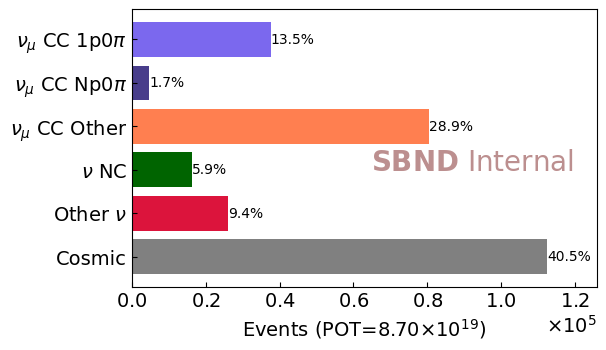

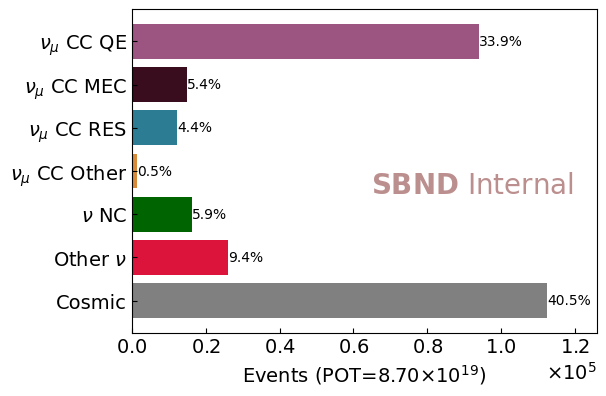

In [11]:
stage_key = "is_clear_cosmic"

mc_df, data_df, intime_df, dirt_df = (
    cut_clear_cosmic(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

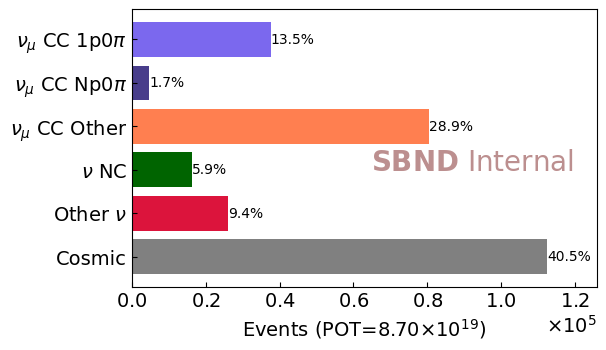

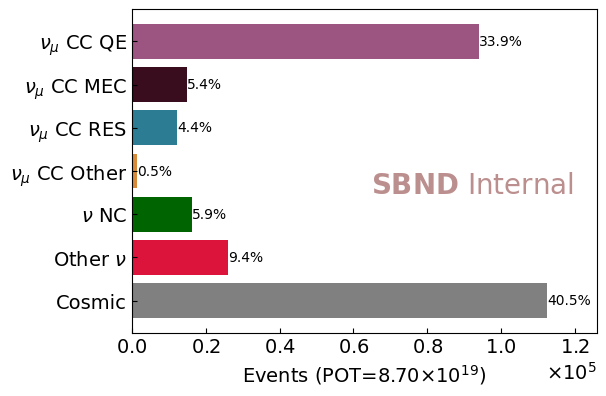

In [12]:
stage_key = "vertex_in_fv"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_vertex_in_fv(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3299: RuntimeWarning: invalid value encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3300: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3301: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


overlay_hists: could not load category_syst_summary ("Variable 'nu_score' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


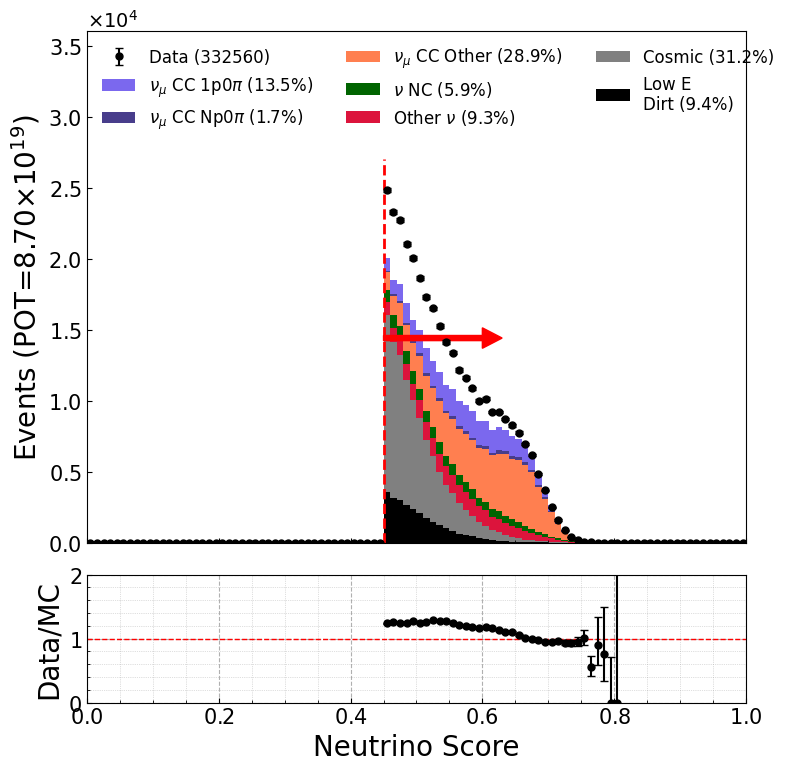

In [13]:
var_config = VariableConfig.nu_score()
plot_labels = ["Neutrino Score", "Events (POT={})".format(pot_str), ""]

for plot_type in ["topology"]:
    save_name = save_fig_dir + "/selected-{}_{}.png".format("nu_score", plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                  mc_df=mc_df, 
                                  data_df=data_df, 
                                  intime_df=intime_df, 
                                  dirt_df=dirt_df,
                                  ratio=True,
                                  ax_ylim_ratio=1.8,
                                  vline=[[0.45, 1]],
                                  var_config=var_config,
                                  plot_labels=plot_labels,
                                  save_fig=save_fig, 
                                  save_name=save_name)

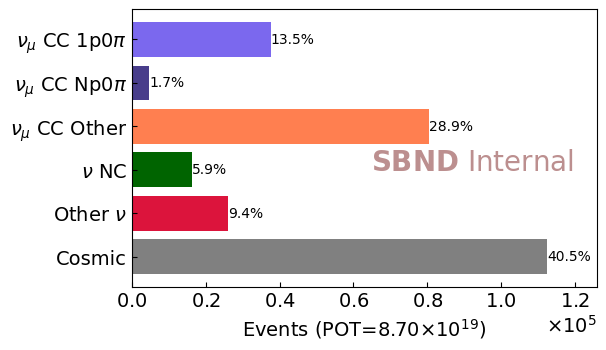

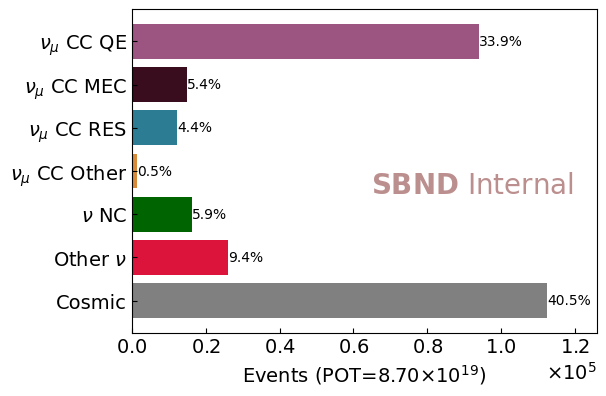

In [14]:
stage_key = "nu_score"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_nu_score(df, NU_SCORE_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

## Slice has two tracks

In [15]:
# TODO: this is for det var samples
# TODO: move to dfmaker
# def get_chi2_avg(trkdf, pid_branch):
#     avg_val = avg_chi2(mc_trk_df, pid_branch)
#     trkdf[("pfp", "trk", "chi2pid", "avg", pid_branch, "")] = avg_val
#     return trkdf

# mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
#     get_chi2_avg(df, "chi2_muon")
#     for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
# )

# mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
#     get_chi2_avg(df, "chi2_proton")
#     for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
# )

In [16]:
# chimu_avg = avg_chi2(mc_trk_df, "chi2_muon")
# mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
# chip_avg = avg_chi2(mc_trk_df, "chi2_proton")
# mc_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

# chimu_avg = avg_chi2(data_trk_df, "chi2_muon")
# data_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
# chip_avg = avg_chi2(data_trk_df, "chi2_proton")
# data_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

# chimu_avg = avg_chi2(intime_trk_df, "chi2_muon")
# intime_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
# chip_avg = avg_chi2(intime_trk_df, "chi2_proton")
# intime_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

# chimu_avg = avg_chi2(dirt_trk_df, "chi2_muon")
# dirt_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
# chip_avg = avg_chi2(dirt_trk_df, "chi2_proton")
# dirt_trk_df[("pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(mc_df.trk1, "chi2_muon")
mc_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(mc_df.trk1, "chi2_proton")
mc_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(data_df.trk1, "chi2_muon")
data_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(data_df.trk1, "chi2_proton")
data_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(intime_df.trk1, "chi2_muon")
intime_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(intime_df.trk1, "chi2_proton")
intime_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(offbeam_df.trk1, "chi2_muon")
offbeam_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(offbeam_df.trk1, "chi2_proton")
offbeam_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(dirt_df.trk1, "chi2_muon")
dirt_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(dirt_df.trk1, "chi2_proton")
dirt_df[("trk1", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(mc_df.trk2, "chi2_muon")
mc_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(mc_df.trk2, "chi2_proton")
mc_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(data_df.trk2, "chi2_muon")
data_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(data_df.trk2, "chi2_proton")
data_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(intime_df.trk2, "chi2_muon")
intime_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(intime_df.trk2, "chi2_proton")
intime_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(offbeam_df.trk2, "chi2_muon")
offbeam_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(offbeam_df.trk2, "chi2_proton")
offbeam_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

chimu_avg = avg_chi2(dirt_df.trk2, "chi2_muon")
dirt_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_muon", "")] = chimu_avg
chip_avg = avg_chi2(dirt_df.trk2, "chi2_proton")
dirt_df[("trk2", "pfp", "trk", "chi2pid", "avg", "chi2_proton", "")] = chip_avg

In [17]:
# mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
#     get_valid_trks(df)
#     for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
# )

# mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
#     match_trkdf_to_slcdf(trk_df, df)
#     for trk_df, df in ((mc_trk_df, mc_df), (data_trk_df, data_df), (intime_trk_df, intime_df), (offbeam_trk_df, offbeam_df), (dirt_trk_df, dirt_df))
# )

# mc_df, data_df, intime_df, offbeam_df, dirt_df = (
#     get_trk_info(df, trk_df, SAVE_NTRKS)
#     for df, trk_df in ((mc_df, mc_trk_df), (data_df, data_trk_df), (intime_df, intime_trk_df), (offbeam_df, offbeam_trk_df), (dirt_df, dirt_trk_df))
# )

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3299: RuntimeWarning: invalid value encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3300: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3301: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


overlay_hists: could not load category_syst_summary ("Variable 'n_trks' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


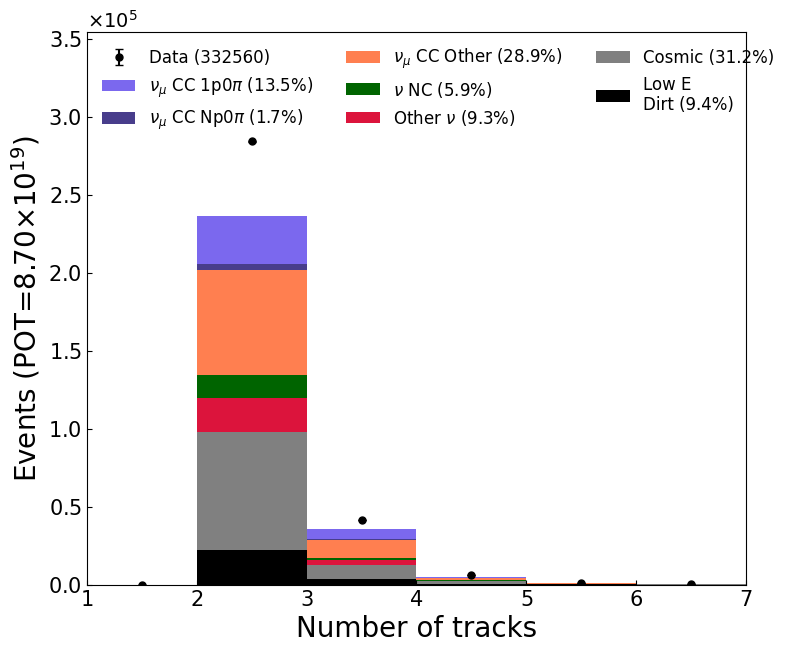

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3299: RuntimeWarning: invalid value encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3300: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3301: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


overlay_hists: could not load category_syst_summary ("Variable 'n_trks' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


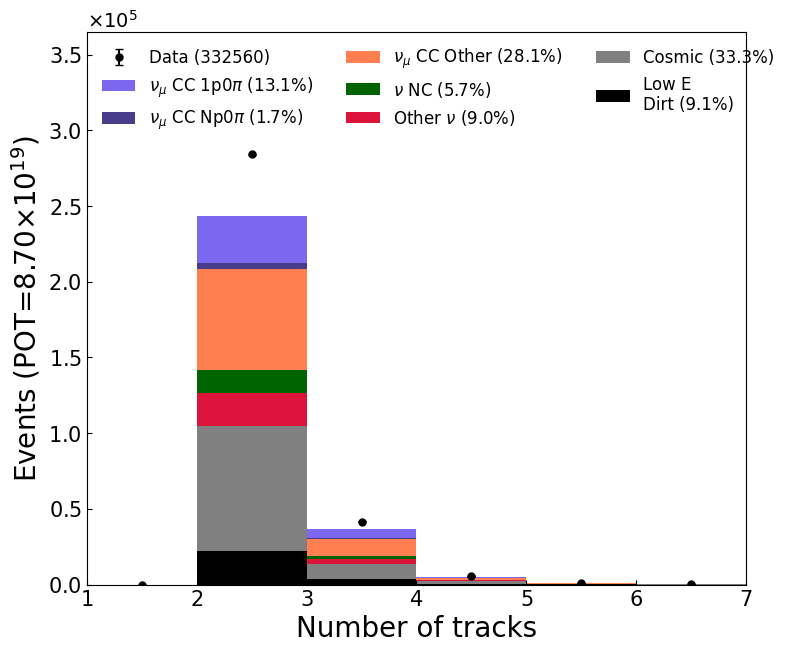

In [18]:
var_config = VariableConfig.n_trks()
plot_labels = ["Number of tracks", "Events (POT={})".format(pot_str), ""]

for plot_type in ["topology"]:
    save_name = save_fig_dir + "/selected-{}_{}.png".format("ntrks", plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                  mc_df=mc_df, 
                                  data_df=data_df, 
                                  intime_df=intime_df, 
                                  dirt_df=dirt_df,
                                  var_config=var_config,
                                  plot_labels=plot_labels,
                                  save_fig=save_fig, 
                                  save_name=save_name)

    save_name = save_fig_dir + "/selected-{}_{}.png".format("ntrks", plot_type)
    ret_hist_topo = overlay_hists(plot_type,
                                  mc_df=mc_df, 
                                  data_df=data_df, 
                                  intime_df=offbeam_df, 
                                  dirt_df=dirt_df,
                                  var_config=var_config,
                                  plot_labels=plot_labels,
                                  save_fig=save_fig, 
                                  save_name=save_name)

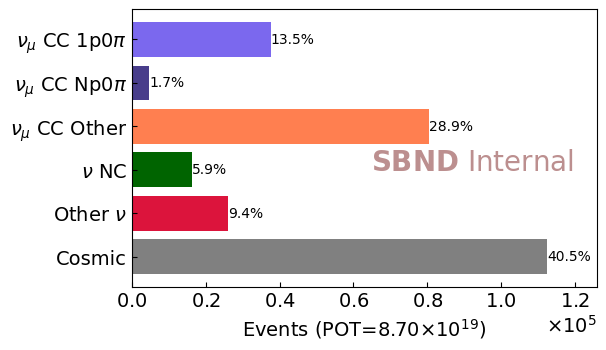

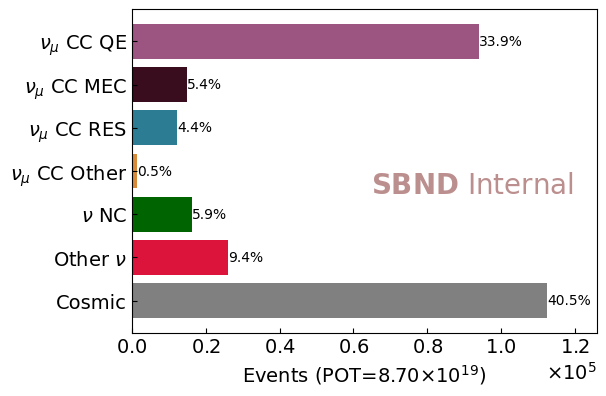

In [19]:
stage_key = "2prong"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

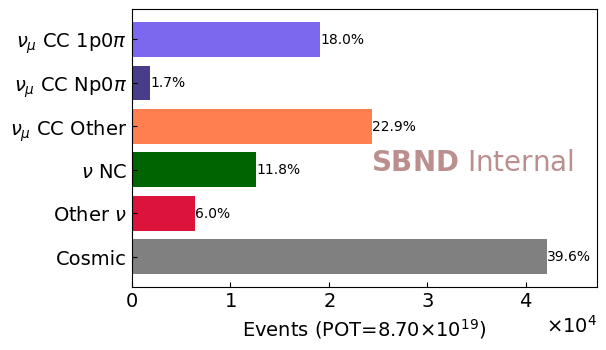

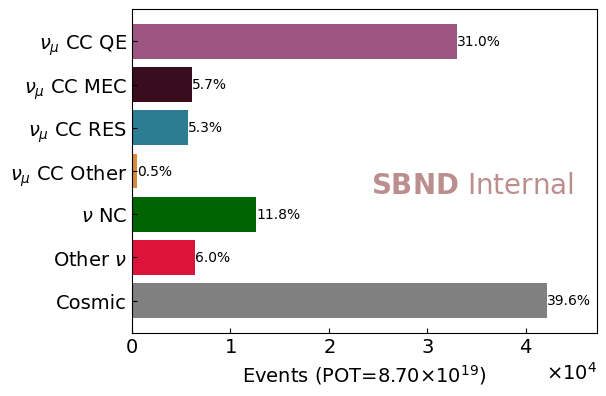

In [20]:
stage_key = "2prong-contained"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [21]:
for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df):
    if 'topo_categ' not in df.columns:
        df.loc[:, 'topo_categ'] = get_topo_category(df)

/tmp/ipykernel_790703/2068043604.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'topo_categ'] = get_topo_category(df)
/tmp/ipykernel_790703/2068043604.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'topo_categ'] = get_topo_category(df)
/tmp/ipykernel_790703/2068043604.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

In [22]:
# WireMod systematics from wiremod.ipynb (sel_2prong matched-event cache)
WIREMOD_CACHE_PATH = (
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/"
    "wiremod_matched_hists-2prong.pkl"
)
WIREMOD_GEOM_LABELS = ("YZ", "XTXW")  # unisim geometries (exclude CV reference dataset)
WIREMOD_KNOB_TAGS = {"YZ": "wiremod_yz", "XTXW": "wiremod_xtxw"}
WIREMOD_VAR_COLORS = {"YZ": "C0", "XTXW": "C1", "CV": "C2"}
CALO_PARAMS = ("ccal", "alpha", "beta", "R")
WIREMOD_SHIFTED_UNIVERSES = tuple(f"{c}_{s}" for c in CALO_PARAMS for s in ("p", "m"))


def load_wiremod_hists(cache_path):
    """Load pickle written by wiremod.ipynb ``save_wiremod_hists``."""
    with open(cache_path, "rb") as fh:
        payload = pickle.load(fh)
    print(
        f"Loaded WireMod cache: {len(payload['variations'])} variations, "
        f"{len(payload['universes'])} universes, "
        f"{len(payload['var_defs'])} variables",
        flush=True,
    )
    return payload


def _rebin_counts(counts, old_bins, new_bins):
    old_bins = np.asarray(old_bins, dtype=float)
    new_bins = np.asarray(new_bins, dtype=float)
    counts = np.asarray(counts, dtype=float)
    old_centers = 0.5 * (old_bins[:-1] + old_bins[1:])
    rebinned, _ = np.histogram(old_centers, bins=new_bins, weights=counts)
    return rebinned


def _wiremod_counts_at_var_bins(hists, var_name, universe, cache_bins, target_bins):
    counts = np.asarray(hists[universe][var_name], dtype=float)
    if len(cache_bins) - 1 != len(target_bins) - 1 or not np.allclose(cache_bins, target_bins):
        counts = _rebin_counts(counts, cache_bins, target_bins)
    return counts


def _shifted_univ_keys(hists, shifted_univs=None):
    if shifted_univs is not None:
        return [u for u in shifted_univs if u in hists]
    return [u for u in hists if u != "cv"]


def _draw_calo_envelope(ax, hists, var_name, bins, color, shifted_univs, normalize=True):
    keys = _shifted_univ_keys(hists, shifted_univs)
    if not keys:
        return
    rows = []
    for u in keys:
        cnt = np.asarray(hists[u][var_name], dtype=float)
        total = cnt.sum()
        if total == 0:
            continue
        rows.append(cnt / total if normalize else cnt)
    if not rows:
        return
    shifted = np.stack(rows, axis=0)
    lo, hi = shifted.min(axis=0), shifted.max(axis=0)
    ax.fill_between(
        bins,
        np.append(lo, lo[-1]),
        np.append(hi, hi[-1]),
        step="post",
        color=color,
        alpha=0.2,
    )


def plot_wiremod_var_comparison(
    var_name,
    plot_var_cfg,
    all_hists,
    shifted_univs=None,
    normalize=True,
    ratio=True,
):
    """WireMod YZ / XTXW / CV comparison for the cv calorimetry universe."""
    bins = np.asarray(plot_var_cfg["bins"], dtype=float)
    fig, axes = plt.subplots(
        2 if ratio else 1,
        1,
        figsize=(7, 6),
        gridspec_kw={"height_ratios": [3, 1]} if ratio else None,
        sharex=True,
    )
    if ratio:
        fig.subplots_adjust(hspace=0.1)
        ax_top, ax_bot = axes
    else:
        ax_top, ax_bot = axes, None

    reference_counts = None
    reference_label = None
    for var_label, hists in all_hists.items():
        counts = np.asarray(hists["cv"][var_name], dtype=float)
        total = counts.sum()
        if total == 0:
            continue
        if normalize:
            counts = counts / total
        color = WIREMOD_VAR_COLORS.get(var_label)
        ax_top.step(
            bins,
            np.append(counts, counts[-1]),
            where="post",
            label=var_label,
            color=color,
            linewidth=1.5,
        )
        _draw_calo_envelope(
            ax_top, hists, var_name, bins, color, shifted_univs, normalize=normalize
        )
        if reference_counts is None:
            reference_counts = counts.copy()
            reference_label = var_label

    ax_top.set_ylabel("Events (normalised)" if normalize else "Events")
    ax_top.set_title(plot_var_cfg.get("label", var_name), fontsize=10)
    ax_top.legend(fontsize=9)

    if ratio and ax_bot is not None and reference_counts is not None:
        for var_label, hists in all_hists.items():
            counts = np.asarray(hists["cv"][var_name], dtype=float)
            total = counts.sum()
            if total == 0:
                continue
            if normalize:
                counts = counts / total
            with np.errstate(divide="ignore", invalid="ignore"):
                rat = np.where(reference_counts > 0, counts / reference_counts, np.nan)
            color = WIREMOD_VAR_COLORS.get(var_label)
            ax_bot.step(
                bins,
                np.append(rat, rat[-1]),
                where="post",
                label=var_label,
                color=color,
                linewidth=1.5,
            )
            _draw_calo_ratio_envelope(
                ax_bot,
                hists,
                var_name,
                bins,
                color,
                reference_counts,
                shifted_univs,
                normalize=normalize,
            )
        ax_bot.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
        ax_bot.set_ylabel(f"Ratio to {reference_label}")
        ax_bot.set_ylim(0.85, 1.15)
        ax_bot.legend(fontsize=8, ncol=3)

    ax_top.set_xlim(bins[0], bins[-1])
    if ax_bot is not None:
        ax_bot.set_xlabel(plot_var_cfg.get("label", var_name))
    else:
        ax_top.set_xlabel(plot_var_cfg.get("label", var_name))
    fig.tight_layout()
    return fig


def _draw_calo_ratio_envelope(
    ax, hists, var_name, bins, color, reference_counts, shifted_univs, normalize=True
):
    keys = _shifted_univ_keys(hists, shifted_univs)
    if not keys or reference_counts is None:
        return
    rows = []
    for u in keys:
        cnt = np.asarray(hists[u][var_name], dtype=float)
        total = cnt.sum()
        if total == 0:
            continue
        if normalize:
            cnt = cnt / total
        with np.errstate(divide="ignore", invalid="ignore"):
            rows.append(np.where(reference_counts > 0, cnt / reference_counts, np.nan))
    if not rows:
        return
    shifted = np.stack(rows, axis=0)
    lo, hi = np.nanmin(shifted, axis=0), np.nanmax(shifted, axis=0)
    ax.fill_between(
        bins,
        np.append(lo, lo[-1]),
        np.append(hi, hi[-1]),
        step="post",
        color=color,
        alpha=0.2,
    )


def _sanitize_matrix_pack(ret):
    return {
        k: np.nan_to_num(np.asarray(ret[k], dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
        for k in ("cov", "cov_frac", "corr")
    }


def max_envelope_univ_counts(n_cv, hists, var_name, shifted_univs):
    """Per-bin CV + larger-magnitude shift among all calo-shift universes."""
    n_cv = np.asarray(n_cv, dtype=float)
    keys = _shifted_univ_keys(hists, shifted_univs)
    if not keys:
        return n_cv.copy()
    stacked = np.stack(
        [np.asarray(hists[u][var_name], dtype=float) for u in keys],
        axis=0,
    )
    lo, hi = stacked.min(axis=0), stacked.max(axis=0)
    diffs_hi = hi - n_cv
    diffs_lo = lo - n_cv
    pick_hi = np.abs(diffs_hi) >= np.abs(diffs_lo)
    chosen = np.where(pick_hi, diffs_hi, diffs_lo)
    # 1σ = max |envelope − CV| (same as syst_detvar_aggregate.unisim_per_calo)
    return n_cv + chosen


def cov_pack_two_universe(n_cv, n_var):
    ret = get_covariance_matrix(
        np.asarray([n_var], dtype=float),
        np.asarray(n_cv, dtype=float),
    )
    return _sanitize_matrix_pack(ret)


def build_wiremod_unisim_cov(
    all_hists,
    var_name,
    geom_labels,
    shifted_univs,
    cache_bins,
    target_bins=None,
):
    """One 2-universe unisim per WireMod geometry; sum cov_frac (independent knobs)."""
    if target_bins is None:
        target_bins = cache_bins

    per_geom = {}
    cov_frac_total = None
    n_cv_ref = None

    for geom in geom_labels:
        if geom not in all_hists:
            continue
        hists = all_hists[geom]
        if "cv" not in hists or var_name not in hists["cv"]:
            continue

        n_cv = _wiremod_counts_at_var_bins(
            hists, var_name, "cv", cache_bins, target_bins
        )
        if n_cv.sum() <= 0:
            continue

        hists_reb = {
            u: {
                vn: (
                    _wiremod_counts_at_var_bins(hists, vn, u, cache_bins, target_bins)
                    if vn == var_name
                    else np.asarray(hists[u][vn], dtype=float)
                )
                for vn in hists[u]
            }
            for u in hists
        }
        n_var = max_envelope_univ_counts(
            n_cv, hists_reb, var_name, shifted_univs
        )
        pack = cov_pack_two_universe(n_cv, n_var)
        per_geom[geom] = {
            "tag": WIREMOD_KNOB_TAGS[geom],
            **pack,
            "n_cv": n_cv,
            "n_var": n_var,
        }

        if cov_frac_total is None:
            cov_frac_total = pack["cov_frac"].copy()
            n_cv_ref = n_cv
        else:
            cov_frac_total = cov_frac_total + pack["cov_frac"]

    if not per_geom:
        raise KeyError(f"No WireMod histograms found for variable '{var_name}'")

    return per_geom, cov_frac_total, n_cv_ref


# ── Load cache (payload keys: hists, var_defs, universes, …) ─────────────────
wiremod_payload = load_wiremod_hists(WIREMOD_CACHE_PATH)
wiremod_hists = wiremod_payload["hists"]
wiremod_var_defs = wiremod_payload["var_defs"]
wiremod_shifted = [u for u in wiremod_payload["universes"] if u != "cv"]


Loaded WireMod cache: 3 variations, 9 universes, 7 variables


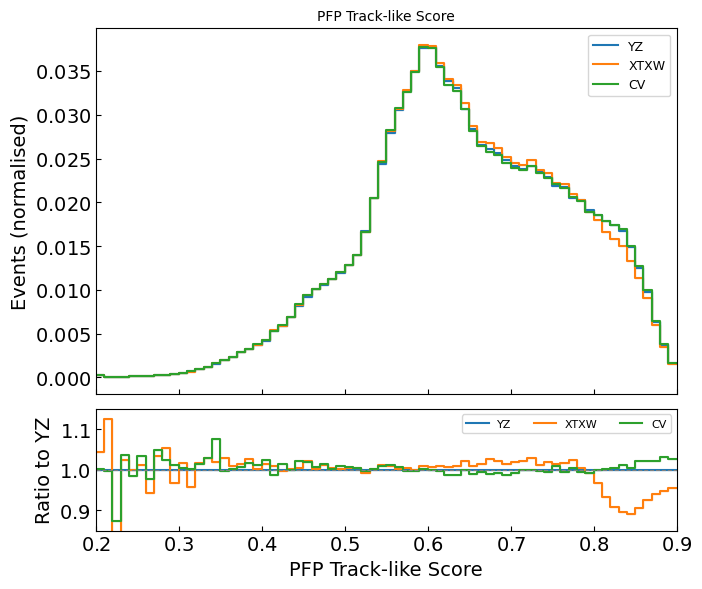

WireMod unisim knobs:
  YZ (wiremod_yz): median fractional uncertainty = nan
  XTXW (wiremod_xtxw): median fractional uncertainty = nan
Combined wiremod_cov_frac shape: (70, 70)


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [23]:
var_config = VariableConfig.track_score()
variable_name = var_config.var_save_name
if variable_name not in wiremod_var_defs:
    raise KeyError(
        f"{variable_name!r} not in WireMod cache "
        f"(available: {sorted(wiremod_var_defs)})"
    )

plot_var_cfg = {
    "label": var_config.var_labels[0] if var_config.var_labels else variable_name,
    "bins": np.asarray(var_config.bins, dtype=float),
}
cache_bins = np.asarray(wiremod_var_defs[variable_name]["bins"], dtype=float)
if len(cache_bins) - 1 != len(plot_var_cfg["bins"]) - 1 or not np.allclose(
    cache_bins, plot_var_cfg["bins"]
):
    print(
        f"Rebinning WireMod histograms for {variable_name}: "
        f"{len(cache_bins) - 1} cache bins -> {len(plot_var_cfg['bins']) - 1} var_config bins"
    )

# Plot matched-event histograms across WireMod geometry variations
fig_wiremod = plot_wiremod_var_comparison(
    variable_name,
    wiremod_var_defs[variable_name],
    wiremod_hists,
    shifted_univs=wiremod_shifted,
    normalize=True,
    ratio=True,
)
plt.show()

# unisim covariance: one 2-universe matrix per geometry (CV vs max calo envelope)
wiremod_syst_by_geom, wiremod_cov_frac, wiremod_n_cv = build_wiremod_unisim_cov(
    wiremod_hists,
    variable_name,
    WIREMOD_GEOM_LABELS,
    wiremod_shifted,
    cache_bins=cache_bins,
    target_bins=plot_var_cfg["bins"],
)
wiremod_syst = {
    "by_geom": wiremod_syst_by_geom,
    "cov_frac_total": wiremod_cov_frac,
    "n_cv": wiremod_n_cv,
    "variable": variable_name,
}

print("WireMod unisim knobs:")
for geom, pack in wiremod_syst_by_geom.items():
    diag = np.sqrt(np.maximum(np.diag(pack["cov_frac"]), 0.0))
    print(
        f"  {geom} ({pack['tag']}): "
        f"median fractional uncertainty = {np.median(diag[diag > 0]):.3f}"
    )
print(f"Combined wiremod_cov_frac shape: {wiremod_cov_frac.shape}")


In [24]:
VAR_DEFS = {
    # ── chi2 (priority variables) ─────────────────────────────────────────
    "chi2_mu": {
        "label": VariableConfig.chi2_mu().var_labels[0],
        "bins":  VariableConfig.chi2_mu().bins,
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_muon_new")),
    },
    "chi2_p": {
        "label": VariableConfig.chi2_proton().var_labels[0],
        "bins":  VariableConfig.chi2_proton().bins,
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_proton_new")),
    },
    # ── track shape ───────────────────────────────────────────────────────
    "track_score": {
        "label": VariableConfig.track_score().var_labels[0],
        "bins":  VariableConfig.track_score().bins,
        "extract": lambda df: _per_trk_col(df, ("pfp", "trackScore", "", "", "", "")),
    },
    "trk_len": {
        "label": VariableConfig.trk_len().var_labels[0],
        "bins":  VariableConfig.trk_len().bins,
        "extract": lambda df: _per_trk_col(df, ("pfp", "trk", "len", "", "", "")),
    },
    "vtx_dist": {
        "label": VariableConfig.vtx_dist().var_labels[0],
        "bins":  VariableConfig.vtx_dist().bins,
        "extract": lambda df: _per_trk_col(df, ("pfp", "pfochar", "vtxdist", "", "", "")),
    },
    # ── kinematics ────────────────────────────────────────────────────────
    "muon_p": {
        "label": VariableConfig.muon_momentum().var_labels[0],
        "bins":  VariableConfig.muon_momentum().bins,
        "extract": lambda df: _per_evt_col(df, ("mu", "pfp", "trk", "P", "p_muon", "", "")),
    },
    "proton_p": {
        "label": VariableConfig.proton_momentum().var_labels[0],
        "bins":  VariableConfig.proton_momentum().bins,
        "extract": lambda df: _per_evt_col(df, ("p", "pfp", "trk", "P", "p_proton", "", "")),
    },
}

# ── Final-selected evt variables (same set as syst_detvar_chunk PER_EVT_PLOTS) ─
from analysis_village.numucc_1p0pi.final_selected_evt_vars import (
    CORE_SELECTED_EVT_VARIABLE_CONFIGS,
    with_final_selected_evt_variables,
)


def var_def_from_config(vc):
    col = vc.var_evt_reco_col
    return {
        "label": vc.var_labels[0] if vc.var_labels else vc.var_plot_name,
        "bins": np.asarray(vc.bins),
        "extract": lambda df, col=col: _per_evt_col(df, col),
    }


_final_evt_configs = with_final_selected_evt_variables(
    list(CORE_SELECTED_EVT_VARIABLE_CONFIGS)
)
_ne_cfg = VariableConfig.neutrino_energy()
if _ne_cfg.var_save_name not in {c.var_save_name for c in _final_evt_configs}:
    _final_evt_configs.append(_ne_cfg)

FINAL_VAR_DEFS = {}
for vc in _final_evt_configs:
    if vc.var_save_name == "integrated":
        # Single-bin integrated rate: all selected events in one histogram bin.
        FINAL_VAR_DEFS["integrated"] = {
            "label": vc.var_labels[0] if vc.var_labels else vc.var_plot_name,
            "bins": np.asarray(vc.bins),
            "extract": lambda df: np.full(len(df), 500.0, dtype=float),
        }
        continue
    FINAL_VAR_DEFS[vc.var_save_name] = var_def_from_config(vc)

MUP_VAR_DEFS = {**VAR_DEFS, **FINAL_VAR_DEFS}

print(f"Diagnostic variables ({len(VAR_DEFS)}):", list(VAR_DEFS.keys()))
print(f"Final-selected variables for sel_mup ({len(FINAL_VAR_DEFS)}):", list(FINAL_VAR_DEFS.keys()))

Diagnostic variables (7): ['chi2_mu', 'chi2_p', 'track_score', 'trk_len', 'vtx_dist', 'muon_p', 'proton_p']
Final-selected variables for sel_mup (24): ['integrated', 'muon-p', 'muon-dir_z', 'proton-p', 'proton-dir_z', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_p', 'tki-del_alpha', 'tki-del_phi', 'muon-dir_phi', 'proton-dir_phi', 'muon-dir_x', 'muon-dir_y', 'proton-dir_x', 'proton-dir_y', 'vertex_x', 'vertex_y', 'vertex_z', 'muon-end_x', 'muon-end_y', 'muon-end_z', 'E_nu']


In [25]:
import matplotlib.patches as mpatches

CALO_PARAMS = ("ccal", "alpha", "beta", "R")
ALL_UNIVERSES = ("cv",) + tuple(f"{c}_{s}" for c in CALO_PARAMS for s in ("p", "m"))
UNIVERSES_TO_PLOT = list(ALL_UNIVERSES)


VAR_COLORS = {"YZ": "C0", "XTXW": "C1", "CV": "C2"}

# Figure aspect matches overlay / universe plots in utils.py
UNIV_FIGSIZE = (8.5, 7)
UNIV_RATIO_FIGSIZE = (8.5, 8.5)
UNIV_RATIO_HEIGHT_RATIOS = [4, 1]

PLOT_VAR_DEFS = {
    n: {"label": c["label"], "bins": np.asarray(c["bins"])}
    for n, c in VAR_DEFS.items()
}
DIAG_VAR_NAMES = list(PLOT_VAR_DEFS.keys())


example_hists = next(iter(wiremod_hists.values()))
available_univs = [u for u in ALL_UNIVERSES if u in example_hists]
shifted_univs = [u for u in available_univs if u != "cv"]

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# var_keys = [("chi2_mu", r"$\chi^2_{\mu, avg}$"),
            #  ("chi2_p",  r"$\chi^2_{p, avg}$")]

In [26]:
def get_syst(mc_df, dirt_df, intime_df, offbeam_df, evt_var_config, trk_var_config):
    n_univ = 100
    cov_frac_tot = np.zeros((len(evt_var_config.bin_centers), len(evt_var_config.bin_centers)))

    # One bin axis throughout: every component (MC universes, cosmics, wiremod)
    # must be binned with evt_var_config.bins, which is also how the saved npy
    # is interpreted when plotting. trk_var_config can carry different bins
    # (e.g. chi2_proton_trk1: 0-300 vs chi2_proton: 0-350), so override them
    # while keeping its (trk1-prefixed) column.
    trk_var_config = VariableConfig(
        var_save_name=trk_var_config.var_save_name,
        var_plot_name=trk_var_config.var_plot_name,
        var_labels=list(trk_var_config.var_labels),
        bins=evt_var_config.bins,
        var_evt_reco_col=trk_var_config.var_evt_reco_col,
        var_evt_truth_col=trk_var_config.var_evt_truth_col,
        var_nu_col=trk_var_config.var_nu_col,
        xsec_label=trk_var_config.xsec_label,
    )

    # MC systs
    for syst_name in [("mc", "G4"), ("mc", "Flux"), ("mc", "GENIE")]:
        univ, cv = get_univ_rates(
            "rate",
            evtdf=mc_df,
            nudf=None,
            bkgd_subtract=False,
            var_config=trk_var_config,
            syst_name=syst_name,
            n_univ=n_univ,
            verbose=False,
        )

        mats = get_covariance_matrix(univ, cv)
        this_cov_frac = mats["cov_frac"]
        cov_frac_tot += this_cov_frac


    # cosmic systs
    intime_scores = pd.concat([intime_df.trk1[evt_var_config.var_evt_reco_col], intime_df.trk2[evt_var_config.var_evt_reco_col]])
    intime_weights = np.full_like(intime_scores, fill_value=intime_df.pot_weight.values[0], dtype=float)
    offbeam_scores = pd.concat([offbeam_df.trk1[evt_var_config.var_evt_reco_col], offbeam_df.trk2[evt_var_config.var_evt_reco_col]])
    offbeam_weights = np.full_like(offbeam_scores, fill_value=offbeam_df.pot_weight.values[0], dtype=float)

    # Histogram 
    intime_hist, _ = np.histogram(intime_scores, bins=evt_var_config.bins, weights=intime_weights)
    offbeam_hist, _ = np.histogram(offbeam_scores, bins=evt_var_config.bins, weights=offbeam_weights)

    print(f"intime_hist: {intime_hist}")
    print(f"offbeam_hist: {offbeam_hist}")

    # Scale intime↔offbeam relative difference by the cosmic fraction of the
    # total prediction. Do not force cosmic_frac=1 — that applied the full
    # cosmic model difference as a fractional unc. on the entire sample.
    n_cosmics = len(offbeam_df) * intime_df.pot_weight.values[0]
    n_tot = (
        len(mc_df) * mc_df.pot_weight.values[0]
        + len(dirt_df) * dirt_df.pot_weight.values[0]
        + n_cosmics
    )
    cosmic_frac = (n_cosmics / n_tot) if n_tot > 0 else 0.0
    print(f"cosmic_frac: {cosmic_frac}")
    with np.errstate(divide="ignore", invalid="ignore"):
        cosmic_frac_shift = np.where(
            intime_hist > 0,
            cosmic_frac * ((intime_hist - offbeam_hist) / intime_hist),
            0.0,
        )
    syst_vals = np.nan_to_num(cosmic_frac_shift, nan=0.0, posinf=0.0, neginf=0.0) ** 2
    # Construct diagonal covariance matrix
    syst = np.diag(syst_vals)

    # cov_frac_tot = np.nan_to_num(cov_frac_tot + syst, nan=0.0, posinf=0.0, neginf=0.0)

    # # wiremod
    # var_name = evt_var_config.var_save_name
    # var_title = evt_var_config.var_labels[0]
    # bins = plot_var_cfg["bins"] if var_name == variable_name else PLOT_VAR_DEFS[var_name]["bins"]

    # fig, ax = plt.subplots()
    # frac_unc_dict = {}
    # for wm_label, hists in wiremod_hists.items():
    #     color = VAR_COLORS.get(wm_label, None)
    #     # Make sure the "cv" and var_name exist in hists
    #     if "cv" not in hists or var_name not in hists["cv"]:
    #         continue
    #     cv_cnt = hists["cv"][var_name]
    #     total = cv_cnt.sum()
    #     if total == 0:
    #         continue
    #     cv_norm = cv_cnt / total if total > 0 else np.zeros_like(cv_cnt)
    #     ax.step(bins, np.append(cv_norm, cv_norm[-1]),
    #             where="post", color=color, linewidth=2,
    #             label=f"{wm_label}")

    #     if shifted_univs:
    #         shifted = []
    #         for u in shifted_univs:
    #             # Make sure the universe and variable exist in hists
    #             if u in hists and var_name in hists[u]:
    #                 s = hists[u][var_name]
    #                 denom = s.sum() if s.sum() > 0 else 1
    #                 shifted.append(s / denom)
    #         if shifted:
    #             shifted = np.stack(shifted, axis=0)
    #             lo = np.nanmin(shifted, axis=0)
    #             hi = np.nanmax(shifted, axis=0)
    #             ax.fill_between(
    #                 bins, np.append(lo, lo[-1]), np.append(hi, hi[-1]),
    #                 step="post", color=color, alpha=0.2
    #             )
    #         frac_unc = ((hi - lo) / 2) / cv_norm
    #         frac_cov_mat = np.diag(frac_unc ** 2)
    #         cov_frac_tot += frac_cov_mat
    #         frac_unc_dict[wm_label] = frac_unc

    # # Add a legend entry for the envelope
    # envelope_patch = mpatches.Patch(color='gray', alpha=0.2, label="Calorimetry variation envelope")
    # handles, labels = ax.get_legend_handles_labels()
    # if not any(lbl == "Calorimetry variation envelope" for lbl in labels):
    #     handles.append(envelope_patch)
    #     labels.append("Calorimetry variation envelope")

    # ax.set_xlabel(var_title)
    # ax.set_xlim(bins[0], bins[-1])
    # ax.set_ylabel("Tracks ")
    # # ax.legend(handles, labels, fontsize=12, frameon=False)
    # # ax.set_title(var_title)

    # plt.tight_layout()
    # plt.show()

    return cov_frac_tot

intime_hist: [7.01852618e-01 1.05277893e+00 7.01852618e-01 1.57916839e+00
 2.45648416e+00 3.50926309e+00 4.73750517e+00 6.49213671e+00
 7.36945249e+00 1.31597366e+01 1.22824208e+01 1.61426102e+01
 2.43893785e+01 3.05305889e+01 4.17602308e+01 6.35176619e+01
 7.73792511e+01 9.56274192e+01 1.18437629e+02 1.54758502e+02
 2.01256238e+02 2.97234584e+02 3.79877729e+02 5.18318158e+02
 6.86060934e+02 8.25203215e+02 8.43802310e+02 8.56611120e+02
 8.23624047e+02 7.90812437e+02 7.06941049e+02 6.14471967e+02
 5.88854346e+02 5.62710336e+02 5.99908525e+02 6.07979830e+02
 5.92363609e+02 5.48848747e+02 5.13580653e+02 4.57958833e+02
 4.17075918e+02 3.86720792e+02 3.60225856e+02 3.43907783e+02
 3.12499878e+02 2.98989215e+02 2.64072047e+02 2.58808153e+02
 2.52140553e+02 2.40910911e+02 2.32839606e+02 2.10204859e+02
 2.03537259e+02 1.90903912e+02 1.76515933e+02 1.55460355e+02
 1.43704323e+02 1.29842734e+02 1.16156608e+02 8.79070404e+01
 8.73806509e+01 6.63250724e+01 5.75519147e+01 4.52694938e+01
 3.49171677

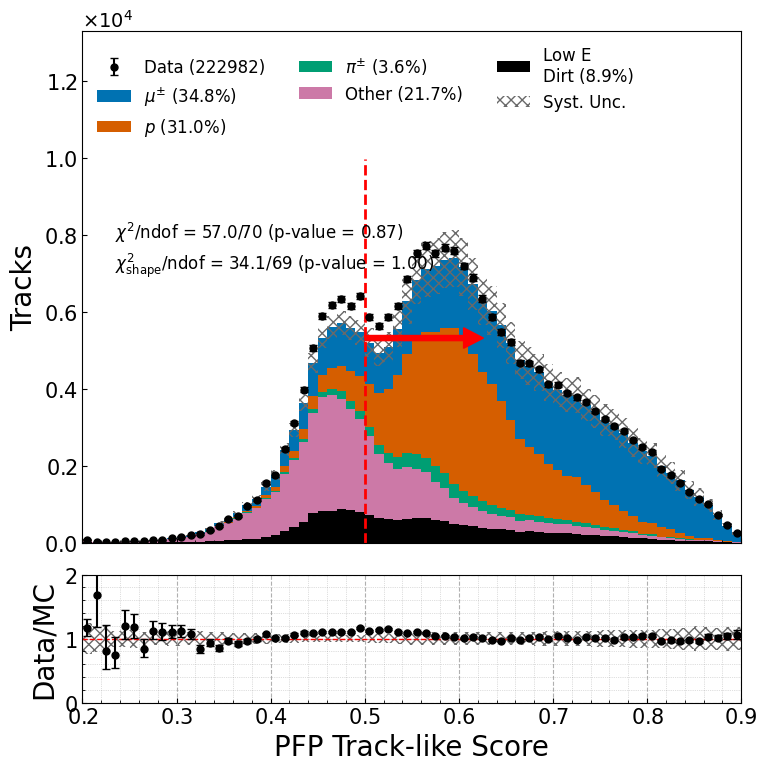

In [27]:
plot_type = "pdg"


var_config_evt = VariableConfig.track_score()
var_config_trk = VariableConfig.track_score_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)

var_config = VariableConfig.track_score()

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                         mc_df=mc_trk_df, 
                         data_df=data_trk_df, 
                         intime_df=intime_trk_df, 
                         dirt_df=dirt_trk_df,
                         syst=syst,
                         syst_decomp = False,
                         ratio=True,
                         textchi2=True,
                         ax_ylim_ratio=1.8,
                         vline=[[0.5, 1]],
                         var_config=var_config,
                         plot_labels=plot_labels,
                         approval="",
                         save_fig=save_fig, 
                         save_name=save_name)

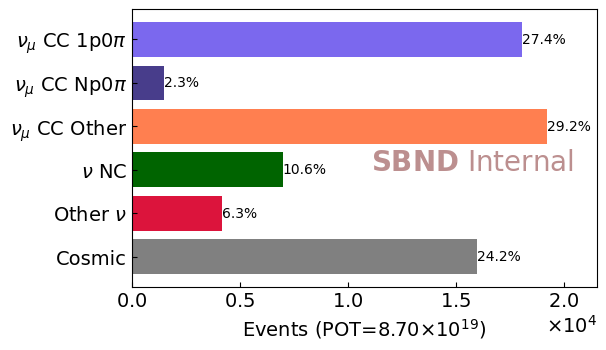

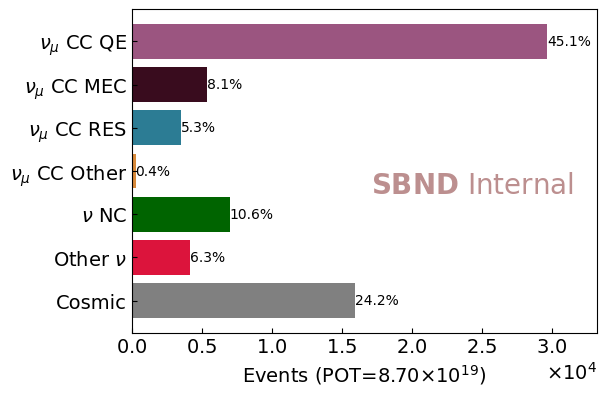

In [28]:
stage_key = "2prong-trackscore"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

intime_hist: [285.65401544 704.66002827 786.42585824 736.59432238 604.64603023
 491.12136931 398.47682376 329.16887775 291.26883639 237.22618482
 195.81688037 162.12795471 135.45755524 105.45335582  92.29361924
  80.18666158  64.39497768  50.53338848  36.84726243  35.61902035
  32.98707304  25.26669424  24.03845216  19.82733645  17.19538914
  14.38797866  16.84446283  13.8615892   18.59909437  10.52778927
   8.94862088   9.29954719   7.54491564   7.7203788    8.42223141
   5.43935779   7.54491564   5.43935779   7.01852618   5.08843148]
offbeam_hist: [213.33852932 632.53774259 774.17693113 729.96966887 632.09786934
 542.8035983  466.2656517  372.13277485 335.18342132 286.79736312
 235.99200202 181.22778161 156.59487925 121.844892   110.62812397
  87.75471464  77.19775648  60.48257274  56.08384018  45.96675529
  37.82910004  29.03163492  25.29271224  21.99366282  22.43353607
  20.45410642  19.13448665  14.73575409  14.95569072  12.31645118
   8.79746513  10.55695815  10.33702152   8.1376

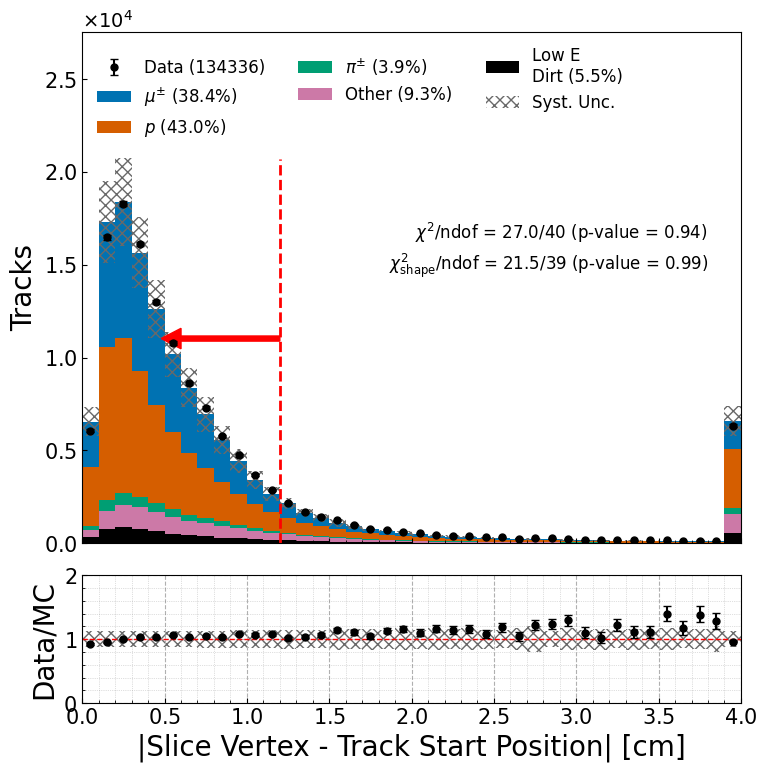

In [29]:
plot_type = "pdg"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

var_config_evt = VariableConfig.vtx_dist()
var_config_trk = VariableConfig.vtx_dist_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
var_config = var_config_evt

plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=intime_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=syst,
                                syst_decomp=False,
                                ratio=True,
                                textchi2=True,
                                vline=[[VTXDIST_TH, 0]],
                                var_config=var_config,
                                plot_labels=plot_labels,
                                approval="",
                                save_fig=save_fig, 
                                save_name=save_name)

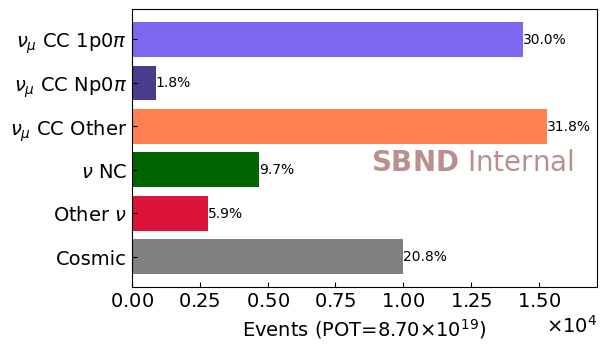

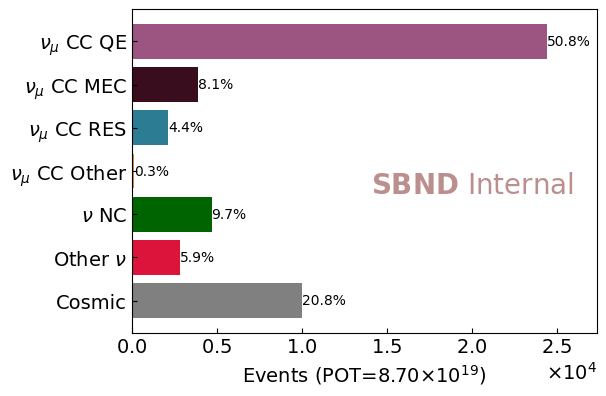

In [30]:
stage_key = "2prong-vtxdist"

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, offbeam_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_offbeam, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, offbeam_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

## PID

In [31]:
mc_trk_df_ = mc_trk_df.copy()
data_trk_df_ = data_trk_df.copy()
intime_trk_df_ = intime_trk_df.copy()
offbeam_trk_df_ = offbeam_trk_df.copy()
dirt_trk_df_ = dirt_trk_df.copy()

intime_hist: [7.56246196e+02 8.17131910e+02 5.70781641e+02 2.84952163e+02
 2.15117827e+02 1.71427502e+02 1.45985345e+02 1.20543187e+02
 9.87857560e+01 8.82579667e+01 8.01866616e+01 7.43963775e+01
 6.49213671e+01 5.91310830e+01 5.01824622e+01 4.50940307e+01
 3.91282834e+01 4.24620834e+01 3.82509677e+01 3.31625362e+01
 3.71981887e+01 3.15833678e+01 2.80741047e+01 2.47403048e+01
 1.94764101e+01 2.19328943e+01 1.56162207e+01 1.35106629e+01
 1.45634418e+01 1.22824208e+01 9.82593665e+00 1.01768630e+01
 7.54491564e+00 7.19398933e+00 7.19398933e+00 5.61482094e+00
 5.26389463e+00 4.38657886e+00 4.03565255e+00 4.56204202e+00
 2.28102101e+00 3.68472624e+00 2.98287363e+00 2.80741047e+00
 1.22824208e+00 1.40370524e+00 3.50926309e-01 8.77315772e-01
 5.26389463e-01 5.26389463e-01]
offbeam_hist: [1077.90941462  681.36367405  431.95553771  208.27998687  166.05215426
  131.08223038  131.74204027  114.58698327  108.42875768   88.19458789
   85.55534836   77.85756637   69.93984776   65.10124194   57.62339

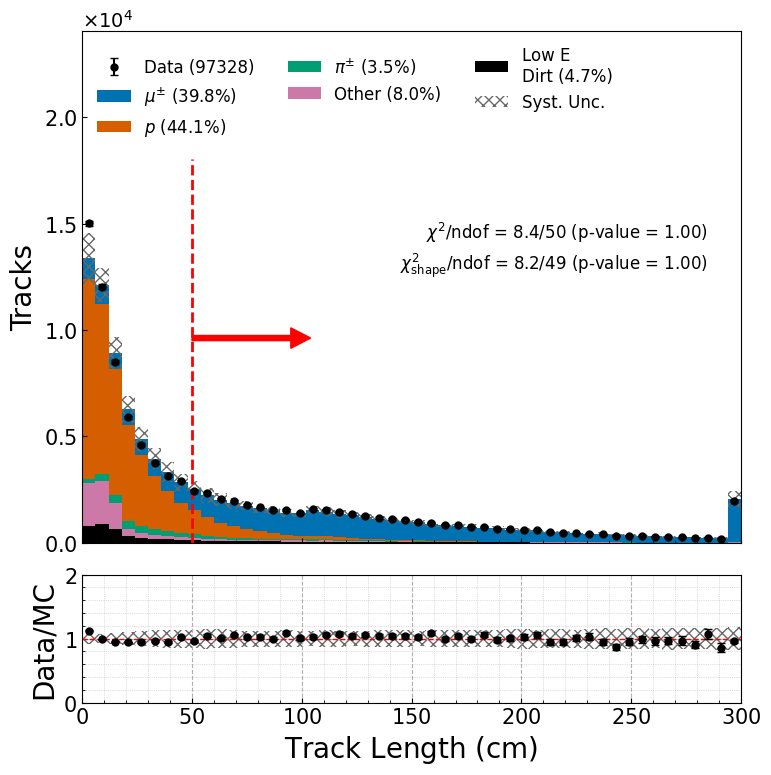

In [32]:
# all tracks in 2-track slices
plot_type = "pdg"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

var_config_evt = VariableConfig.trk_len()
var_config_trk = VariableConfig.trk_len_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
var_config = var_config_evt
            
plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=offbeam_trk_df, 
                                dirt_df=dirt_trk_df,
                                ratio=True,
                                ax_ylim_ratio=1.8,
                                syst=syst,
                                textchi2=True,
                                vline=[[MU_LEN_TH,1]],
                                var_config=var_config,
                                approval="",
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

intime_hist: [7.56246196e+02 8.17131910e+02 5.70781641e+02 2.84952163e+02
 2.15117827e+02 1.71427502e+02 1.45985345e+02 1.20543187e+02
 9.87857560e+01 8.82579667e+01 8.01866616e+01 7.43963775e+01
 6.49213671e+01 5.91310830e+01 5.01824622e+01 4.50940307e+01
 3.91282834e+01 4.24620834e+01 3.82509677e+01 3.31625362e+01
 3.71981887e+01 3.15833678e+01 2.80741047e+01 2.47403048e+01
 1.94764101e+01 2.19328943e+01 1.56162207e+01 1.35106629e+01
 1.45634418e+01 1.22824208e+01 9.82593665e+00 1.01768630e+01
 7.54491564e+00 7.19398933e+00 7.19398933e+00 5.61482094e+00
 5.26389463e+00 4.38657886e+00 4.03565255e+00 4.56204202e+00
 2.28102101e+00 3.68472624e+00 2.98287363e+00 2.80741047e+00
 1.22824208e+00 1.40370524e+00 3.50926309e-01 8.77315772e-01
 5.26389463e-01 5.26389463e-01]
offbeam_hist: [1077.90941462  681.36367405  431.95553771  208.27998687  166.05215426
  131.08223038  131.74204027  114.58698327  108.42875768   88.19458789
   85.55534836   77.85756637   69.93984776   65.10124194   57.62339

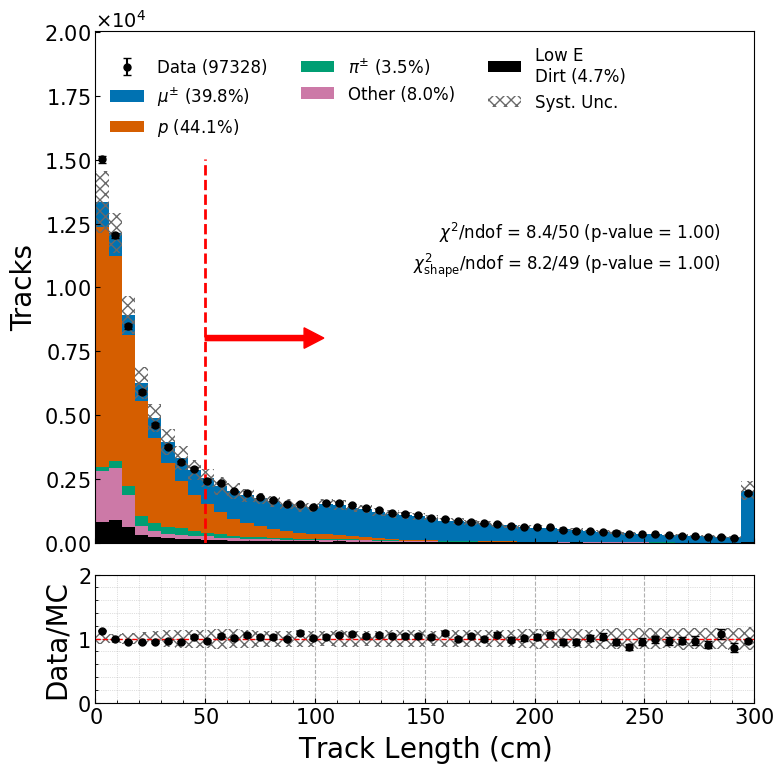

In [33]:
# all tracks in 2-track slices
plot_type = "pdg"

mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

var_config_evt = VariableConfig.trk_len()
var_config_trk = VariableConfig.trk_len_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
var_config = var_config_evt
            
plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=offbeam_trk_df, 
                                dirt_df=dirt_trk_df,
                                ratio=True,
                                # ax_ylim_ratio=0.4,
                                syst=syst,
                                textchi2=True,
                                vline=[[MU_LEN_TH,1]],
                                var_config=var_config,
                                approval="",
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

In [34]:
def get_mcs_range_diff(trks):
    mcs_range_diff = (trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon
    trks[("pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
    return trks


mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_mcs_range_diff(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

In [35]:
def get_mcs_range_diff_trk1(df):
    mcs_range_diff = (df.trk1.pfp.trk.rangeP.p_muon - df.trk1.pfp.trk.mcsP.fwdP_muon) / df.trk1.pfp.trk.rangeP.p_muon
    df[("trk1", "pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
    return df

def get_mcs_range_diff_trk2(df):
    mcs_range_diff = (df.trk2.pfp.trk.rangeP.p_muon - df.trk2.pfp.trk.mcsP.fwdP_muon) / df.trk2.pfp.trk.rangeP.p_muon
    df[("trk2", "pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
    return df

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    get_mcs_range_diff_trk1(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

mc_df, data_df, intime_df, offbeam_df, dirt_df = (
    get_mcs_range_diff_trk2(df)
    for df in (mc_df, data_df, intime_df, offbeam_df, dirt_df)
)

/tmp/ipykernel_790703/1426068806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[("trk1", "pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
/tmp/ipykernel_790703/1426068806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[("trk1", "pfp", "trk", "mcs_range_diff", "", "", "")] = mcs_range_diff
/tmp/ipykernel_790703/1426068806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

intime_hist: [ 21.40650484  22.28382062  21.581968    17.01992598  20.00279961
  24.21391531  29.47780995  26.49493632  20.70465223  30.00419941
  24.03845216  25.7930837   32.46068357  29.6532731   36.32087297
  39.83013606  41.2338413   43.16393599  46.84866224  46.49773593
  49.12968325  58.25376728  72.29081963  75.44915641  74.7473038
  86.32787199  97.90844018 105.27789267 126.3334712  129.14088168
 106.85706106  83.34499836  48.25236747  40.18106237  29.30234679
  25.61762055  16.31807336  14.56344182   8.59769457   4.73750517]
offbeam_hist: [ 15.83543723  11.21676804  15.83543723  12.97626106  14.51581746
  17.37499362  19.35442328  18.69461339  20.67404305  25.51264887
  28.37182503  25.95252212  28.59176166  27.05220526  30.35125469
  37.38922679  34.96992388  42.66770586  40.90821284  45.08700877
  53.66453727  63.34174891  67.30060822  76.09807334 103.15027861
 109.08856757 130.20248387 159.89392867 184.08695777 176.38917579
 155.27525948  98.53160942  63.12181228  50.80536

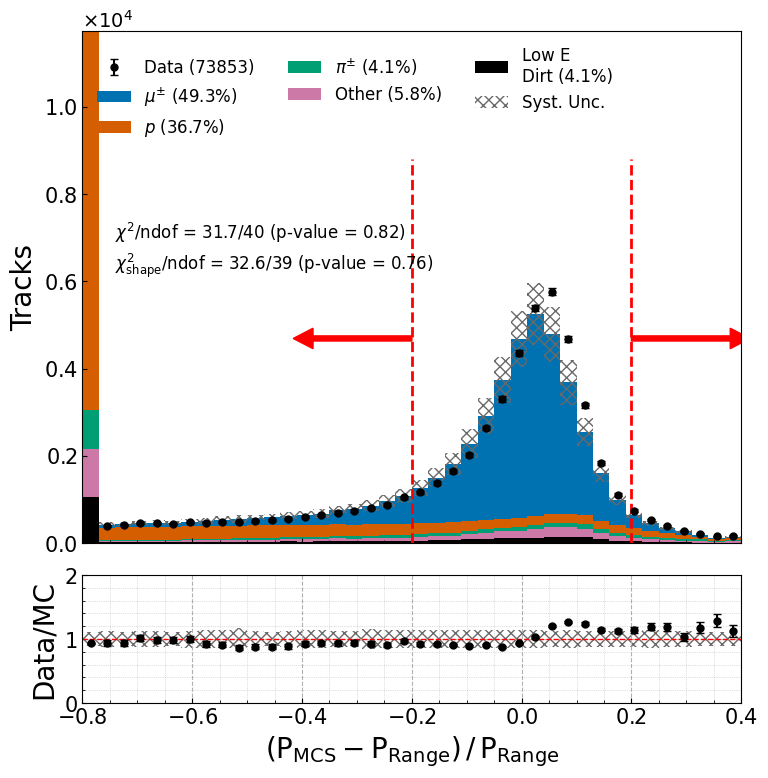

In [36]:
mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    get_mcs_range_diff(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)


var_config_evt = VariableConfig.mcs_range_diff()
var_config_trk = VariableConfig.mcs_range_diff_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
var_config = var_config_evt

plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist_chi2mu = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=offbeam_trk_df, 
                                dirt_df=dirt_trk_df,
                                ratio=True,
                                syst=syst,
                                textchi2=True,
                                vline=[[-QUAL_TH,0], [QUAL_TH,1]],
                                ax_ylim_ratio=0.5,
                                var_config=var_config,
                                plot_labels=plot_labels,
                                approval="",
                                save_fig=save_fig, 
                                save_name=save_name)

intime_hist: [1.54407576e+01 3.71981887e+01 6.22894198e+01 7.22908196e+01
 8.61524088e+01 1.04049651e+02 1.35106629e+02 1.87921038e+02
 2.31084974e+02 2.75652616e+02 2.32137753e+02 1.85990944e+02
 1.55284892e+02 1.64935365e+02 1.63005270e+02 1.68269165e+02
 1.50371923e+02 1.43353397e+02 1.34580239e+02 1.27386250e+02
 1.30720050e+02 1.09138082e+02 9.08899140e+01 8.19412931e+01
 7.05361881e+01 5.57972831e+01 4.31639360e+01 3.43907783e+01
 3.77245782e+01 3.36889257e+01 3.36889257e+01 3.21097573e+01
 3.33379993e+01 3.47417046e+01 3.57944835e+01 3.40398520e+01
 4.56204202e+01 3.82509677e+01 4.07074518e+01 3.96546729e+01
 4.61468096e+01 3.42153151e+01 3.38643888e+01 2.15819680e+01
 1.64935365e+01 1.05277893e+01 1.07032524e+01 5.61482094e+00
 3.50926309e+00 4.38657886e+00 1.75463154e+00 1.93009470e+00
 1.40370524e+00 8.77315772e-01 1.05277893e+00 1.05277893e+00
 8.77315772e-01 5.26389463e-01 1.75463154e-01 3.50926309e-01]
offbeam_hist: [  9.23733838  35.40979713 107.10913791 136.14077283 112.

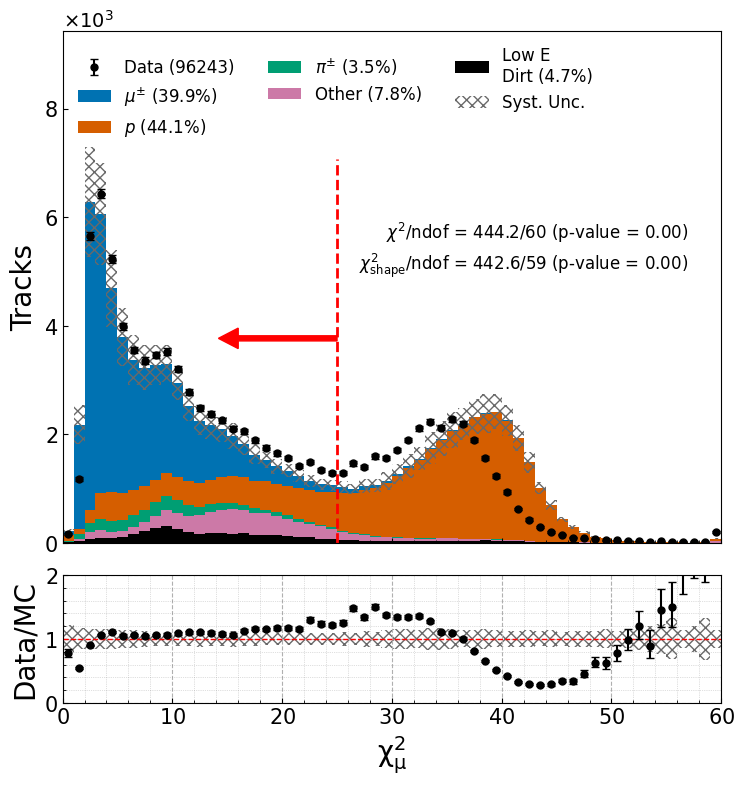

In [37]:
mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

var_config_evt = VariableConfig.chi2_mu()
var_config_trk = VariableConfig.chi2_mu_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
# np.save("syst_array_chi2mu.npy", syst)
# loaded_syst = np.load("syst_array_chi2mu_trk1.npy", allow_pickle=True)
var_config = var_config_evt

plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist_chi2mu = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=offbeam_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=syst,
                                syst_decomp = False,
                                textchi2=True,
                                ratio=True,
                                vline=[[MU_CHI2MU_TH, 0]],
                                approval="",
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

intime_hist: [140.72144987 158.44322847  79.30934581  56.32367258  36.14540982
  33.33799935  27.89864156  27.7231784   27.7231784   30.00419941
  28.60049418  25.96854686  27.89864156  25.7930837   27.37225209
  32.10975726  33.16253619  40.18106237  52.46348318  65.27229346
  80.71305105  89.13528246  79.66027212  80.18666158  70.53618809
  60.88571459  55.27089365  62.81580929  66.32507238  75.62461957
  82.11675628 107.03252421 124.57883966 142.47608141 178.97241754
 193.00946989 210.55578534 204.76550124 201.60716446 195.46595406
 173.18213344 142.82700772 102.99687166  80.36212474  59.65747251
  40.18106237  32.28522042  24.21391531  16.31807336  13.33519974
   7.7203788    6.84306302   5.26389463   4.56204202   2.80741047
   2.80741047   2.45648416   2.80741047   1.57916839   1.40370524]
offbeam_hist: [ 26.83226864  56.74365007  47.50631168  34.09017737  18.03480351
  17.37499362  17.155057    13.85600757  15.83543723  13.63607095
  16.05537386  14.95569072  11.65664129  12.3164

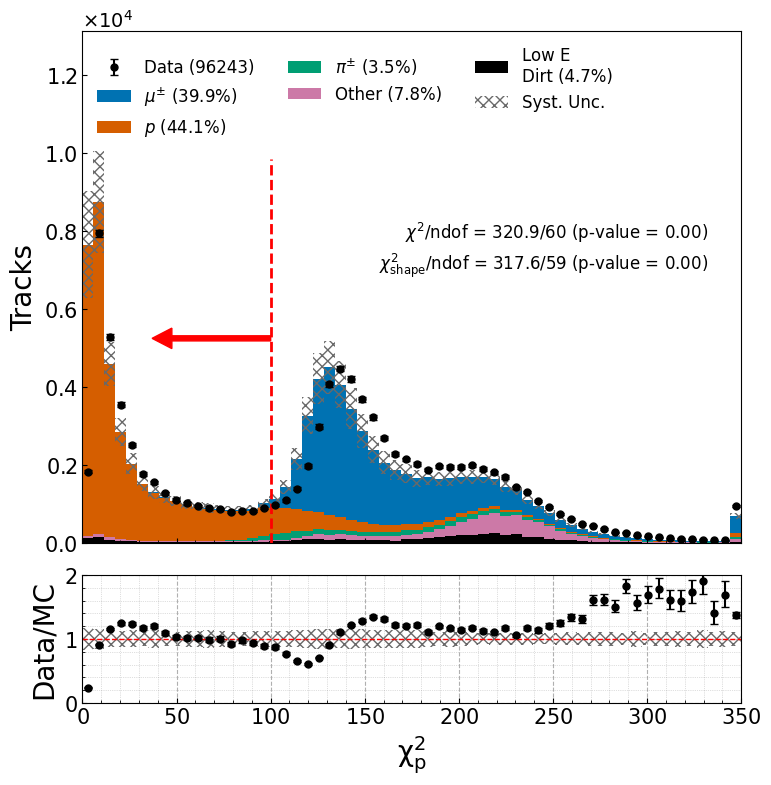

In [38]:
mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

var_config_evt = VariableConfig.chi2_proton()
var_config_trk = VariableConfig.chi2_proton_trk1()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
# np.save("syst_array_chi2proton.npy", syst)
# loaded_syst = np.load("syst_array_chi2mu_trk1.npy", allow_pickle=True)
var_config = var_config_evt

plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist_chi2proton = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=offbeam_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=syst,
                                syst_decomp = False,
                                textchi2=True,
                                ratio=True,
                                vline=[[MU_CHI2P_TH, 0]],
                                approval="",
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

In [39]:
for df in (mc_df, data_df, intime_df, dirt_df, offbeam_df):
    df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk1", "pfp", "trk", "dir", "x", "", "")],
            df[("trk1", "pfp", "trk", "dir", "y", "", "")],
        )
    )
    df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk2", "pfp", "trk", "dir", "x", "", "")],
            df[("trk2", "pfp", "trk", "dir", "y", "", "")],
        )
    )

    df[("trk1", "pfp", "trk", "truth", "p", "phi", "")] = np.degrees(
        np.arctan2(
            df[("trk1", "pfp", "trk", "truth", "p", "dir", "x")],
            df[("trk1", "pfp", "trk", "truth", "p", "dir", "y")],
        )
    )
    df[("trk2", "pfp", "trk", "truth", "p", "phi", "")] = np.degrees(
        np.arctan2(
            df[("trk2", "pfp", "trk", "truth", "p", "dir", "x")],
            df[("trk2", "pfp", "trk", "truth", "p", "dir", "y")],
        )
    )


/tmp/ipykernel_790703/2596715901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_790703/2596715901.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_790703/2596715901.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

intime_hist: [ 99.13668226 113.34919777 110.89271361 106.15520844  98.08390334
  86.6787983   77.20378796  69.48340916  60.53478829  51.58616741
  50.88431479  60.18386198  70.71165124  99.83853488 131.07097637
 153.00387068 171.4275019  167.21638619 137.56311309 107.55891368
 119.66587133 145.80988135 168.26916512 168.97101774 163.35619679
 130.01819745 101.59316643  76.50193534  64.74590399  57.72737781
  50.35792533  63.1667356   66.32507238  76.67739849  83.69592467
 106.50613475 115.80568194 113.87558724 115.27929247  92.8200087 ]
offbeam_hist: [ 89.95408092 107.7689478  134.38127981 141.85912516 128.44299085
 108.20882106  88.41452452  62.90187565  52.78479076 102.05059547
  95.23255999  55.20409367  77.63762974  96.77211639 120.74520886
 129.76261062 153.73570309 151.75627343 135.26102632 101.39078558
 110.18825071 140.31956877 172.21037985 147.13760424 143.17874493
 121.18508212  83.13604545  72.13921404  59.82276286 133.72146992
 134.16134318  55.64396692  57.62339658  80.2768

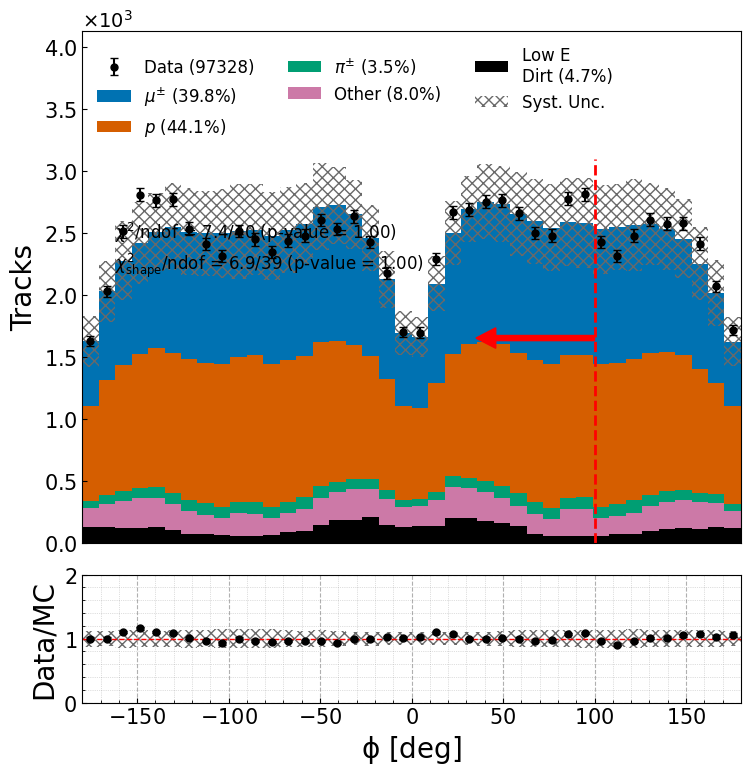

In [40]:
mc_trk_df = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_df["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_df = pd.concat([data_df.trk1, data_df.trk2])
data_trk_df["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_df = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_df["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_df = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_df["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_df = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_df["pot_weight"] = dirt_df.pot_weight.values[0]

var_config_evt = VariableConfig.trk_direction_phi()
var_config_trk = VariableConfig.trk1_direction_phi()

syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)
np.save("syst_array_phi.npy", syst)
# loaded_syst = np.load("syst_array_chi2mu_trk1.npy", allow_pickle=True)
var_config = var_config_evt

plot_labels = [var_config.var_labels[0], "Tracks", ""]
save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
ret_hist_chi2proton = overlay_hists(plot_type,
                                mc_df=mc_trk_df, 
                                data_df=data_trk_df, 
                                intime_df=offbeam_trk_df, 
                                dirt_df=dirt_trk_df,
                                syst=syst,
                                syst_decomp = False,
                                textchi2=True,
                                ratio=True,
                                vline=[[MU_CHI2P_TH, 0]],
                                approval="",
                                var_config=var_config,
                                plot_labels=plot_labels,
                                save_fig=save_fig, 
                                save_name=save_name)

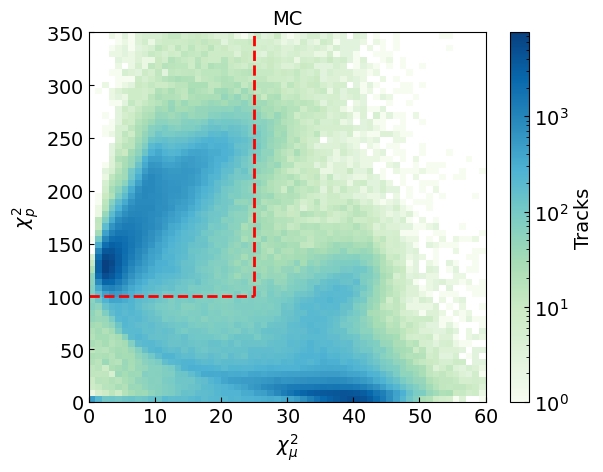

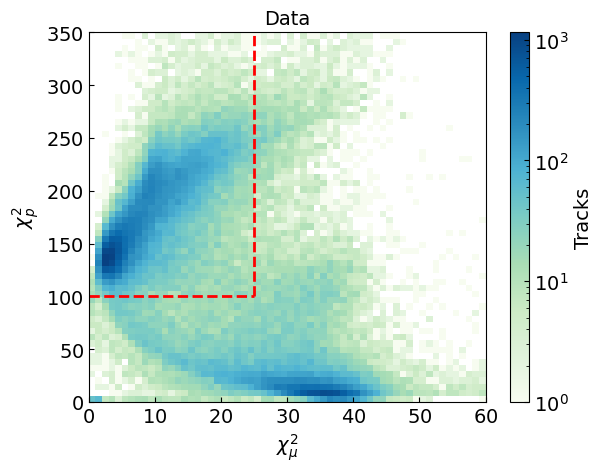

In [41]:
# compare chi2_mu vs. chi2_p 2D distributions and get the percentage out of total of the selected area
from matplotlib.colors import LogNorm

var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

var_1_trk1 = avg_chi2(mc_df.trk1, "chi2_muon").to_numpy(dtype=float)
var_2_trk1 = avg_chi2(mc_df.trk1, "chi2_proton").to_numpy(dtype=float)
var_1_trk2 = avg_chi2(mc_df.trk2, "chi2_muon").to_numpy(dtype=float)
var_2_trk2 = avg_chi2(mc_df.trk2, "chi2_proton").to_numpy(dtype=float)
var_1 = np.concatenate([var_1_trk1, var_1_trk2])
var_2 = np.concatenate([var_2_trk1, var_2_trk2])

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("$\\chi^2_{\\mu}$")
plt.ylabel("$\\chi^2_{p}$")
plt.title("MC")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")

# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC-wcuts.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

var_1_trk1 = avg_chi2(data_df.trk1, "chi2_muon")
var_2_trk1 = avg_chi2(data_df.trk1, "chi2_proton")
var_1_trk2 = avg_chi2(data_df.trk2, "chi2_muon")
var_2_trk2 = avg_chi2(data_df.trk2, "chi2_proton")
var_1 = np.concatenate([var_1_trk1, var_1_trk2])
var_2 = np.concatenate([var_2_trk1, var_2_trk2])

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("$\\chi^2_{\\mu}$")
plt.ylabel("$\\chi^2_{p}$")
plt.title("Data")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")
# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data-wcuts.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [42]:
# muon quality cuts

# tracks after len > 50 cm cut for muon selection
def len_cut(trks):
    trks = trks[trks.pfp.trk.len > 50]
    return trks

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    len_cut(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)


# tracks after quality cut for muon selection
def mcs_range_diff_cut(trks):
    trks = trks[np.abs(trks.pfp.trk.mcs_range_diff) < QUAL_TH]
    return trks

mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df = (
    mcs_range_diff_cut(df)
    for df in (mc_trk_df, data_trk_df, intime_trk_df, offbeam_trk_df, dirt_trk_df)
)

def is_mu_candidate(trks):
    trks = len_cut(trks)
    trks = mcs_range_diff_cut(trks)
    chimu_avg = trks.pfp.trk.chi2pid.avg.chi2_muon
    chip_avg = trks.pfp.trk.chi2pid.avg.chi2_proton
    chi2_cut = (chimu_avg > 0) & (chimu_avg < MU_CHI2MU_TH) & (chip_avg > MU_CHI2P_TH) 
    trks = trks[chi2_cut]
    return trks

def is_not_mu_candidate(trks):
    nlevels = len(mc_df.index.names)
    mcs_range_diff = np.abs((trks.pfp.trk.rangeP.p_muon - trks.pfp.trk.mcsP.fwdP_muon) / trks.pfp.trk.rangeP.p_muon)
    chimu_avg = trks.pfp.trk.chi2pid.avg.chi2_muon
    chip_avg = trks.pfp.trk.chi2pid.avg.chi2_proton
    mu_cut = (chimu_avg > 0) & (chimu_avg < MU_CHI2MU_TH) & \
            (chip_avg > MU_CHI2P_TH) & \
            (trks.pfp.trk.len > MU_LEN_TH) & \
            (mcs_range_diff < QUAL_TH)
    not_mu_candidate = pd.concat([trks[~mu_cut], trks[mu_cut].groupby(level=list(range(nlevels))).nth(1)])
    return not_mu_candidate


In [43]:
# get the percentage of tracks selected as mu

mc_mus = is_mu_candidate(mc_trk_df)
intime_mus = is_mu_candidate(intime_trk_df)
dirt_mus = is_mu_candidate(dirt_trk_df)
data_mus = is_mu_candidate(data_trk_df)

n_mc_mus = len(mc_mus.groupby(level=[0,1,2]).head(1))
n_intime_mus = len(intime_mus.groupby(level=[0,1,2]).head(1))
n_dirt_mus = len(dirt_mus.groupby(level=[0,1,2]).head(1))
n_data_mus = len(data_mus.groupby(level=[0,1,2]).head(1))

print((n_mc_mus + n_intime_mus + n_dirt_mus) / (len(mc_trk_df) + len(intime_trk_df) + len(dirt_trk_df) ))
print(n_data_mus / len(data_trk_df))


0.9479732466480418
0.9540624240952149


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3299: RuntimeWarning: invalid value encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3300: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3301: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc


overlay_hists: could not load category_syst_summary ("Variable 'chi2_mu' not in category summary (have: integrated, muon-dir_z, muon-p, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi)")
no syst provided


TypeError: 'int' object is not subscriptable

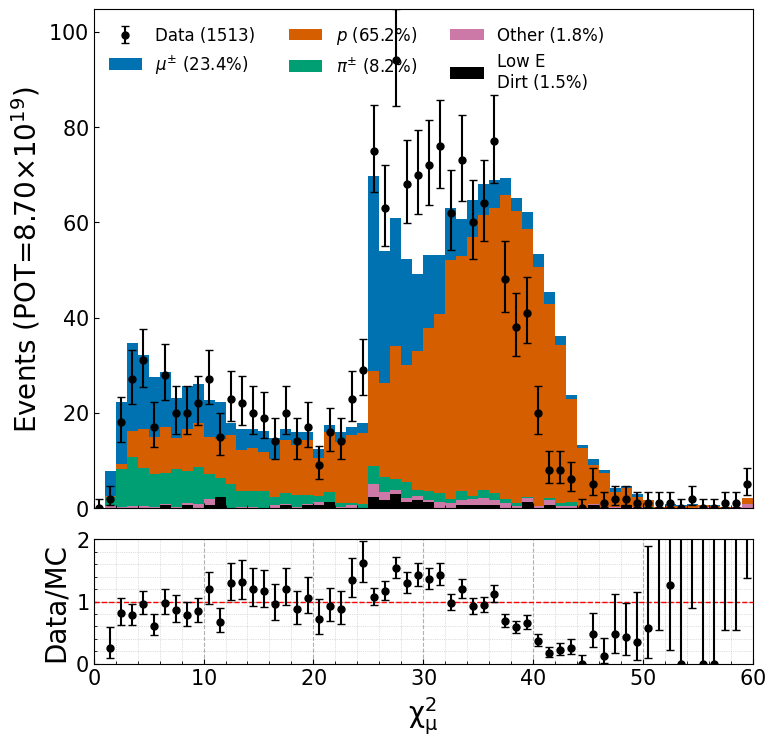

In [ ]:
# tracks that aren't muon candidates
plot_type = "pdg"

mc_notmus = is_not_mu_candidate(mc_trk_df)
data_notmus = is_not_mu_candidate(data_trk_df)
intime_notmus = is_not_mu_candidate(intime_trk_df)
dirt_notmus = is_not_mu_candidate(dirt_trk_df)

for var_config in [VariableConfig.chi2_mu(), 
                   VariableConfig.chi2_proton()]:

    plot_labels = [var_config.var_labels[0], "Events (POT={})".format(pot_str), ""]
    save_name = save_fig_dir + "/2prong-{}_{}".format(var_config.var_save_name, plot_type)
    ret_hist = overlay_hists(plot_type,
                                    mc_df=mc_notmus, 
                                    data_df=data_notmus, 
                                    intime_df=intime_notmus, 
                                    dirt_df=dirt_notmus,
                                    ratio=True,
                                    # vline=[P_CHI2P_TH],
                                    var_config=var_config,
                                    plot_labels=plot_labels,
                                    approval="",
                                    save_fig=save_fig, 
                                    save_name=save_name)

    # with open(f'{save_content_dir}/{syst_tag}_{var_config.var_save_name}-not_mu_candidate.pkl', 'wb') as f:
    #     pickle.dump(ret_hist, f)

In [ ]:
# chi2_proton of tracks that aren't muon candidates — with all systematics (incl. WireMod)
plot_type = "pdg"

# Rebuild track tables from the current evt dfs (do not reuse length/quality-prefiltered trk dfs)
mc_trk_all = pd.concat([mc_df.trk1, mc_df.trk2])
mc_trk_all["pot_weight"] = mc_df.pot_weight.values[0]
data_trk_all = pd.concat([data_df.trk1, data_df.trk2])
data_trk_all["pot_weight"] = data_df.pot_weight.values[0]
intime_trk_all = pd.concat([intime_df.trk1, intime_df.trk2])
intime_trk_all["pot_weight"] = intime_df.pot_weight.values[0]
offbeam_trk_all = pd.concat([offbeam_df.trk1, offbeam_df.trk2])
offbeam_trk_all["pot_weight"] = offbeam_df.pot_weight.values[0]
dirt_trk_all = pd.concat([dirt_df.trk1, dirt_df.trk2])
dirt_trk_all["pot_weight"] = dirt_df.pot_weight.values[0]

mc_notmus = is_not_mu_candidate(mc_trk_all)
data_notmus = is_not_mu_candidate(data_trk_all)
intime_notmus = is_not_mu_candidate(intime_trk_all)
offbeam_notmus = is_not_mu_candidate(offbeam_trk_all)
dirt_notmus = is_not_mu_candidate(dirt_trk_all)

var_config_evt = VariableConfig.chi2_proton()
var_config_trk = VariableConfig.chi2_proton_trk1()
var_config = var_config_evt

# G4 / Flux / GENIE + cosmic (same recipe as other PID distributions)
syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)

# WireMod unisim (YZ + XTXW, CV vs max calo envelope) saved by wiremod.ipynb
WIREMOD_NOT_MU_SYST_NPZ = (
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/"
    "wiremod_syst_not_mu_candidate_I2.npz"
)
_wm_not_mu = np.load(WIREMOD_NOT_MU_SYST_NPZ)
wm_cov_frac = np.asarray(_wm_not_mu["chi2_p_cov_frac"], dtype=float)
wm_bins = np.asarray(_wm_not_mu["chi2_p_bins"], dtype=float)
target_bins = np.asarray(var_config.bins, dtype=float)

if len(wm_bins) - 1 != len(target_bins) - 1 or not np.allclose(wm_bins, target_bins):
    # Rebin fractional cov via CV counts when binning differs
    wm_n_cv = np.asarray(_wm_not_mu["chi2_p_n_cv"], dtype=float)
    old_centers = 0.5 * (wm_bins[:-1] + wm_bins[1:])
    n_cv_reb, _ = np.histogram(old_centers, bins=target_bins, weights=wm_n_cv)
    # Diagonal-only rebin of fractional variance (shape syst → new binning)
    frac_var = np.diag(wm_cov_frac).copy()
    var_reb, _ = np.histogram(old_centers, bins=target_bins, weights=frac_var * np.maximum(wm_n_cv, 0.0))
    with np.errstate(divide="ignore", invalid="ignore"):
        frac_var_reb = np.where(n_cv_reb > 0, var_reb / np.maximum(n_cv_reb, 1e-12), 0.0)
    wm_cov_frac = np.diag(frac_var_reb)
    print(
        f"Rebinning WireMod not-mu chi2_p cov: "
        f"{len(wm_bins) - 1} → {len(target_bins) - 1} bins"
    )

if wm_cov_frac.shape != syst.shape:
    raise ValueError(
        f"WireMod not-mu cov_frac shape {wm_cov_frac.shape} != syst shape {syst.shape}"
    )
syst = syst + wm_cov_frac
print(
    f"Added WireMod not-mu chi2_p cov_frac from {WIREMOD_NOT_MU_SYST_NPZ} "
    f"(median frac. unc. = "
    f"{np.median(np.sqrt(np.maximum(np.diag(wm_cov_frac), 0.0))):.3f})"
)

plot_labels = [var_config.var_labels[0], "Tracks (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}-not_mu_candidate_{}".format(
    var_config.var_save_name, plot_type
)
ret_hist_notmu_chi2p = overlay_hists(
    plot_type,
    mc_df=mc_notmus,
    data_df=data_notmus,
    intime_df=intime_notmus,
    dirt_df=dirt_notmus,
    syst=syst,
    syst_decomp=False,
    textchi2=True,
    ratio=True,
    # vline=[P_CHI2P_TH],
    var_config=var_config,
    plot_labels=plot_labels,
    approval="",
    save_fig=save_fig,
    save_name=save_name,
)


In [ ]:
# compare chi2_mu vs. chi2_p 2D distributions and get the percentage out of total of the selected area
from matplotlib.colors import LogNorm

var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

var_1 = avg_chi2(mc_trk_df, "chi2_muon").to_numpy(dtype=float)
var_2 = avg_chi2(mc_trk_df, "chi2_proton").to_numpy(dtype=float)

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("$\\chi^2_{\\mu}$")
plt.ylabel("$\\chi^2_{p}$")
plt.title("MC")
plt.plot([0,var_config_1.bins[-1]], [P_CHI2P_TH,P_CHI2P_TH], color="red", linestyle="--")

# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC-wcuts-notmus.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

var_1 = avg_chi2(data_trk_df, "chi2_muon").to_numpy(dtype=float)
var_2 = avg_chi2(data_trk_df, "chi2_proton").to_numpy(dtype=float)

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("$\\chi^2_{\\mu}$")
plt.ylabel("$\\chi^2_{p}$")
plt.title("Data")
plt.plot([0,var_config_1.bins[-1]], [P_CHI2P_TH,P_CHI2P_TH], color="red", linestyle="--")
# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data-wcuts-notmus.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [ ]:
mc_df, data_df, intime_df, dirt_df = (
    get_mu_p_candidate(df, 
                       mu_chi2mu_th=MU_CHI2MU_TH, mu_chi2p_th=MU_CHI2P_TH, mu_len_th=MU_LEN_TH, qual_th=QUAL_TH,
                       p_chi2mu_th=-1, p_chi2p_th=P_CHI2P_TH, p_len_th=P_LEN_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

In [ ]:
# chi2_proton of proton-candidate tracks — with all systematics (incl. WireMod) + χ²
plot_type = "pdg"

# Require a proton candidate (get_mu_p_candidate already run on mc/data/intime/dirt)
mc_df_pc, data_df_pc, intime_df_pc, dirt_df_pc = (
    cut_has_p(df) for df in (mc_df, data_df, intime_df, dirt_df)
)

def _proton_cand_trkdf(evt_df):
    """Track-level table for the selected proton candidate (``p`` block)."""
    trk = evt_df.p.copy()
    trk["pot_weight"] = evt_df.pot_weight.values[0]
    return trk

mc_ps = _proton_cand_trkdf(mc_df_pc)
data_ps = _proton_cand_trkdf(data_df_pc)
intime_ps = _proton_cand_trkdf(intime_df_pc)
dirt_ps = _proton_cand_trkdf(dirt_df_pc)

var_config_evt = VariableConfig.chi2_proton()
var_config_trk = VariableConfig.chi2_proton_trk1()
var_config = var_config_evt

# G4 / Flux / GENIE + cosmic
syst = get_syst(mc_df, dirt_df, intime_df, offbeam_df, var_config_evt, var_config_trk)

# WireMod unisim from wiremod.ipynb (mu/p candidate histograms → NPZ)
WIREMOD_P_CAND_SYST_NPZ = (
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/"
    "wiremod_syst_proton_candidate.npz"
)
WIREMOD_P_CAND_HIST_PKL = (
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/"
    "wiremod_matched_hists_candidates.pkl"
)

if path.isfile(WIREMOD_P_CAND_SYST_NPZ):
    _wm_pc = np.load(WIREMOD_P_CAND_SYST_NPZ)
    wm_cov_frac = np.asarray(_wm_pc["chi2_p_cov_frac"], dtype=float)
    wm_bins = np.asarray(_wm_pc["chi2_p_bins"], dtype=float)
    wm_n_cv = np.asarray(_wm_pc["chi2_p_n_cv"], dtype=float)
    print(f"Loaded WireMod proton-candidate syst from {WIREMOD_P_CAND_SYST_NPZ}")
else:
    # Fallback: rebuild cov from the candidate hist cache saved by wiremod.ipynb
    print(
        f"{WIREMOD_P_CAND_SYST_NPZ} not found — building from "
        f"{WIREMOD_P_CAND_HIST_PKL}"
    )
    _payload_pc = load_wiremod_hists(WIREMOD_P_CAND_HIST_PKL)
    _hists_pc = _payload_pc["hists"]
    _vdefs_pc = _payload_pc["var_defs"]
    _shifted_pc = [u for u in _payload_pc["universes"] if u != "cv"]
    wm_bins = np.asarray(_vdefs_pc["chi2_p"]["bins"], dtype=float)
    _by_geom, wm_cov_frac, wm_n_cv = build_wiremod_unisim_cov(
        _hists_pc,
        "chi2_p",
        WIREMOD_GEOM_LABELS,
        _shifted_pc,
        cache_bins=wm_bins,
        target_bins=wm_bins,
    )

target_bins = np.asarray(var_config.bins, dtype=float)
if len(wm_bins) - 1 != len(target_bins) - 1 or not np.allclose(wm_bins, target_bins):
    old_centers = 0.5 * (wm_bins[:-1] + wm_bins[1:])
    n_cv_reb, _ = np.histogram(old_centers, bins=target_bins, weights=wm_n_cv)
    frac_var = np.diag(wm_cov_frac).copy()
    var_reb, _ = np.histogram(
        old_centers, bins=target_bins, weights=frac_var * np.maximum(wm_n_cv, 0.0)
    )
    with np.errstate(divide="ignore", invalid="ignore"):
        frac_var_reb = np.where(n_cv_reb > 0, var_reb / np.maximum(n_cv_reb, 1e-12), 0.0)
    wm_cov_frac = np.diag(frac_var_reb)
    print(
        f"Rebinning WireMod proton-candidate chi2_p cov: "
        f"{len(wm_bins) - 1} → {len(target_bins) - 1} bins"
    )

if wm_cov_frac.shape != syst.shape:
    raise ValueError(
        f"WireMod proton-candidate cov_frac shape {wm_cov_frac.shape} "
        f"!= syst shape {syst.shape}"
    )
# syst = syst + wm_cov_frac
syst = wm_cov_frac
print(
    f"Added WireMod proton-candidate chi2_p cov_frac "
    f"(median frac. unc. = "
    f"{np.median(np.sqrt(np.maximum(np.diag(wm_cov_frac), 0.0))):.3f})"
)

plot_labels = [var_config.var_labels[0], "Tracks (POT={})".format(pot_str), ""]
save_name = save_fig_dir + "/2prong-{}-proton_candidate_{}".format(
    var_config.var_save_name, plot_type
)
ret_hist_pc_chi2p = overlay_hists(
    plot_type,
    mc_df=mc_ps,
    data_df=data_ps,
    intime_df=intime_ps,
    dirt_df=dirt_ps,
    syst=syst,
    syst_decomp=False,
    textchi2=True,
    ratio=True,
    # vline=[P_CHI2P_TH],
    var_config=var_config,
    plot_labels=plot_labels,
    approval="",
    save_fig=save_fig,
    save_name=save_name,
)


In [ ]:
stage_key = "2prong-muX"

mc_df, data_df, intime_df, dirt_df = (
    cut_has_mu(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)
mc_df, data_df, intime_df, dirt_df = (
    cut_mu_kinematics(df, mu_Plo_th=MU_PLO_TH, mu_Phi_th=MU_PHI_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
stage_key = "2prong-mup"

mc_df, data_df, intime_df, dirt_df = (
    cut_has_p(df)
    for df in (mc_df, data_df, intime_df, dirt_df)
)
mc_df, data_df, intime_df, dirt_df = (
    cut_p_kinematics(df, p_Plo_th=P_PLO_TH, p_Phi_th=P_PHI_TH)
    for df in (mc_df, data_df, intime_df, dirt_df)
)

for d, d_dict in zip(
    (mc_df, data_df, intime_df, dirt_df),
    (df_dict, df_dict_data, df_dict_intime, df_dict_dirt)
    ):
    d_dict[stage_key] = d

ret = plot_bar_plots(stage_key, mc_df, intime_df, dirt_df, show_plot=show_plot)
for key in ["topology", "genie"]:
    breakdown_dict[key][stage_key] = ret[key]["perc_list"]

In [ ]:
sel_dfs = {
    "mc_df": mc_df,
    "data_df": data_df,
    "intime_df": intime_df,
    "dirt_df": dirt_df
}

# with open(f'{save_content_dir}/{syst_tag}_sel_mup.pkl', 'wb') as f:
#     pickle.dump(sel_dfs, f)


In [ ]:
save_content_dir

# Event Selection Summary Breakdown Plot

In [ ]:
print(df_dict.keys())
stage_labels = [
    "All reconstructed slices",
    "Not clear cosmic",
    "Vertex in fiducial volume",
    "Nu-score > {}".format(NU_SCORE_TH),
    "Has exactly 2 PFPs",
    "Both PFPs contained",
    "Both PFPs have track score > {}".format(TRACKSCORE_TH),
    "Both track \n(start position - vertex) < {} cm".format(VTXDIST_TH),
    "One track is muon-like",
    "The other is proton-like"
]

In [ ]:
stages = list(breakdown_dict["topology"].keys())[::-1]
y = np.arange(len(stages))
bar_width = 0.3

def stack_bars(ax, data, yoffset, colors, label):
    left = np.zeros(len(stages))
    bars = []
    for i, color in enumerate(colors[:data.shape[1]]):
        b = ax.barh(y + yoffset, data[:, i], bar_width, left=left, color=color, label=label if i == 0 else None)
        bars.append(b)
        left += data[:, i]
    return bars

topo_data = np.array([breakdown_dict["topology"][stage] for stage in stages])[:, ::-1]
genie_data = np.array([breakdown_dict["genie"][stage] for stage in stages])[:, ::-1]

fig, ax = plt.subplots(figsize=(10, 10))
stack_bars(ax, topo_data, -bar_width/2, topology_colors, "Topology")
stack_bars(ax, genie_data,  bar_width/2,  genie_mode_colors, "GENIE")

ax.set_xlabel("Percentage (%)")
ax.set_yticks(y)
ax.set_yticklabels(stage_labels[::-1], fontsize=12)

common_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["gray", "sienna", "crimson", "darkgreen"],
    ["Cosmic", r"Out FV $\nu$", r"In FV other $\nu$", r"In FV $\nu_{\mu}$ NC"]
)]
genie_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["#BFB17C", "#D88A3B", "#2c7c94", "#390C1E", "#9b5580"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC SIS/DIS", r"In FV $\nu_{\mu}$ CC RES", r"In FV $\nu_{\mu}$ CC MEC", r"In FV $\nu_{\mu}$ CC QE"]
)]
topo_patches = [Patch(facecolor=c, label=l) for c, l in zip(
    ["coral", "darkslateblue", "mediumslateblue"],
    [r"In FV $\nu_{\mu}$ CC Other", r"In FV $\nu_{\mu}$ CC Np0$\pi$", r"In FV $\nu_{\mu}$ CC 1p0$\pi$"]
)]

ax.legend(handles=common_patches, loc='upper left', bbox_to_anchor=(0.01,1.18), ncol=4, fontsize=12, frameon=False)
for i, handles in enumerate([genie_patches[::-1], topo_patches[::-1]]):
    ax_i = ax.twinx()
    ax_i.legend(handles=handles, loc='upper left', 
                bbox_to_anchor=(0.01, 1.14 - 0.07*i), # space out
                ncol=3 if i==0 else 4, fontsize=12, frameon=False)
    ax_i.set_yticks([])

if save_fig:
    plt.savefig(f"{save_fig_dir}/event_selection_summary.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [ ]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

ret = overlay_hists(breakdown_type=breakdown_type,
                    var_config=VariableConfig.muon_momentum(),
                    mc_df=mc_df,
                    data_df=data_df,
                    intime_df=intime_df,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    textloc=textloc,
                    approval=approval,
                    plot_labels=plot_labels_hist,
                    syst=None,
                    save_fig=False, 
                    save_name=None)

# Efficiency Curves

In [ ]:
eff_dict = {}
for var_config in [VariableConfig.muon_momentum(), VariableConfig.muon_direction(),
                   VariableConfig.proton_momentum(), VariableConfig.proton_direction()]:
                #    VariableConfig.opening_angle(),
                #    VariableConfig.tki_del_Tp(), VariableConfig.tki_del_p(),
                #    VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi(),]:

   save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
   ret = plot_efficiency(df_dict,
                   stage_labels,
                   var_config, 
                   textloc=[0.05, 1.08],
                   approval="internal", 
                   legend=False,
                   save_fig=save_fig, 
                   save_name=save_name)

   eff_dict[var_config.var_save_name] = ret

In [ ]:
var_config = VariableConfig.neutrino_energy()
save_name = save_fig_dir + "/efficiency-{}.png".format(var_config.var_save_name)
ret = plot_efficiency(df_dict,
                stage_labels,
                var_config, 
                textloc=[0.05, 1.08],
                approval="internal", 
                legend=True,
                save_fig=save_fig, 
                save_name=save_name)

eff_dict[var_config.var_save_name] = ret

In [ ]:
with open(f'{save_fig_dir}/{syst_tag}_eff_dict.pkl', 'wb') as f:
    pickle.dump(eff_dict, f)

In [ ]:
save_content_dir